# Équinoxe 2026 rent increase · CodeML 2026 · JADCO "Clés en main"

**Question:** how much will Collection Équinoxe's rents go up in 2026?

**Short version:** we measure the *annualised growth of effective rent for the same apartment*
(each apartment compared with its own previous lease), separately for renewals and new tenants,
in Québec and in Ontario. We then forecast it for 2026 by reconciling our internal trend with public anchors
(TAL, Statistics Canada rent CPI), and we check the method with a backtest on 2023, 2024 and 2025.

| § | Contents |
|---|---|
| 0 | Libraries, constants, loading and renaming |
| 1 | Definition of the increase we measure |
| 2 | Data audit and data dictionary |
| 3 | Mix effect (why the median lies) |
| 4 | Same-apartment pairs |
| 5 | Concessions: contract vs effective rent |
| 6 | Renewals vs new tenants, QC / ON rules |
| 7 | External data and reconciliation |
| 8 | Forecast `estimate_2026()` |
| 9 | Backtest `backtest()` 2023–2025 |
| 10 | Results, scenarios, building detail, references |

> **Confidentiality:** the CRM extract is never shown row by row; only aggregates appear.

## 0. Setup

### 0.1 Libraries and project location
Imports, plus a small helper that finds the project root (the folder with `data/raw/` in it). We need it because the same
code runs both from `nb/` (one notebook per section) and from the root (the assembled final notebook).

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"lines.linewidth": 2, "axes.grid": True, "grid.alpha": 0.3})  # shared chart style


def find_project_root(start=None):
    """Walk up from the current folder to the first folder that contains data/raw/."""
    here = Path(start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "raw").is_dir():
            return candidate
    raise FileNotFoundError("data/raw/ not found: copy the 4 Équinoxe CSV files into data/raw/ (see README).")


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
EXTERNAL_DIR = PROJECT_ROOT / "data" / "external"
MODELS_DIR = PROJECT_ROOT / "models"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

### 0.2 Constants
Every judgement call we made (years, thresholds, weights) lives here, named once, with a comment saying why.
Nothing further down uses a bare number, so if you disagree with a threshold, this is the one cell to read.

In [2]:
# --- Dates ---
DATA_CUTOFF = pd.Timestamp("2025-12-31")  # CRM extraction date: no data after it
FORECAST_YEAR = 2026                      # year to forecast
BACKTEST_YEARS = (2023, 2024, 2025)       # validation years required by the brief
FIRST_ANALYSIS_YEAR = 2018                # first leases in 2017 -> first pairs in 2018
DAYS_PER_YEAR = 365.25                    # average year (leap years included)
CPI_LAST_KNOWN_MONTH = 11                 # November CPI comes out mid-December: last month known on Dec 31

# --- Unit key and pairing ---
UNIT_KEY = ["prop_code", "unit_code"]     # = sPropCode + sUnitCode. NEVER sSite + sUnitCode (collisions, §2)
MIN_GAP_YEARS = 0.5                       # shorter gap = same lease entered twice, or a short lease that isn't comparable
MAX_GAP_YEARS = 2.5                       # longer gap = the change mixes several years
GAP_DISPLAY_EDGES = (0.9, 1.1, 1.5)       # display only (§4.2): ≈ 1 year, a bit more, clearly more
GAP_SENSITIVITY_BOUNDS = [(0.75, 1.5), (0.9, 1.1), (0.5, 2.5)]  # alternative bounds tested in §4.6

# --- Jurisdictions and lease types ---
PROVINCE_CODE = {"Quebec": "QC", "Ontario": "ON"}      # sState labels -> short codes
LEASE_TYPE_LABEL = {1: "renewal", 0: "turnover"}        # is_renewal -> label (turnover = new tenant)
SEGMENT_COLS = ["province", "lease_type"]               # the model's 4 segments
LARGE_UNIT_MIN_BEDROOMS = 2                             # "large unit" = 2 bedrooms or more (§3)
SECTION_F_WINDOW_YEARS = 5                              # QC: building ready for habitation for <= 5 years (section F of the lease)
ONTARIO_EXEMPTION_DATE = pd.Timestamp("2018-11-15")     # ON: first occupied after this date = exempt from the guideline

# --- Forecast ---
W_INTERNAL = 0.5                 # weight of the internal trend vs the external anchor, fixed beforehand (no reason to favour either)
TREND_WINDOW_YEARS = 3           # last 3 years: smooths the noise without going back before the 2022 inflation shock
MIN_PAIRS_PER_SEGMENT_YEAR = 20  # below this many pairs, a yearly median is too noisy for the trend
DEPTH_PERSISTENCE_CENTRAL = 0.5  # share of last year's deepening of concessions that repeats (neutral between 0 and 1)
DEPTH_PERSISTENCE_LOW = 1.0      # low scenario: concessions keep deepening at the same pace
DEPTH_PERSISTENCE_HIGH = 0.0     # high scenario: concession depth stops growing
TURNOVER_ANCHOR_SOURCE = "cpi"   # anchor for QC turnovers and Ontario: "cpi" (rent CPI) or "cmhc" (CMHC, compared in §9.4)
CMHC_GEO_BY_PROVINCE = {"QC": "Montreal", "ON": "Ottawa"}  # reference CMHC metro area for each province
MIN_PAIRS_PER_CELL = 15          # building x bedrooms bonus: below this, fall back on the segment
N_BOOTSTRAP = 1000               # resamples for the uncertainty interval
BOOTSTRAP_QUANTILES = (0.10, 0.90)  # 80 % interval
RANDOM_SEED = 2026               # reproducibility
SENSITIVITY_W_VALUES = (0.0, 0.25, 0.5, 0.75, 1.0)  # grid read in §9.4 (not used for tuning)
SENSITIVITY_WINDOWS = (1, 2, 3)                     # trend windows tested in §9.4

# --- Display ---
PCT = 100                        # fraction -> percentage (display only; we store fractions)
FIGSIZE = (9, 4.5)
WIDE_FIGSIZE = (12.6, 4.5)       # two charts side by side
NUMERIC_TOLERANCE = 1e-9        # rounding tolerance (rent comparisons, depth < 1)
SOURCE_CRM = "Source: Yardi CRM extract, Équinoxe, as of 2025-12-31; team calculations"
LEASE_TYPE_CHART_LABELS = {"renewal": "renewals", "turnover": "new tenants"}  # chart legends
DASHBOARD_PATH = PROJECT_ROOT / "dashboard" / "equinoxe_dashboard.html"  # dashboard (bonus, §10)


def add_source(fig, text=SOURCE_CRM):
    """Add the source line under a chart."""
    fig.text(0.01, -0.02, text, fontsize="small")

### 0.3 Loading the four files
We read the four CSVs from `data/raw/` exactly as delivered (we never modify or commit them).
What we should get: 1,061 units, 4,302 leases, 3,560 concession lines, 3,857 advertised months.

In [3]:
raw_listings = pd.read_csv(RAW_DIR / "equinoxe_listings.csv")
raw_leases = pd.read_csv(RAW_DIR / "equinoxe_lease_history.csv")
raw_concessions = pd.read_csv(RAW_DIR / "equinoxe_concessions.csv")
raw_asking = pd.read_csv(RAW_DIR / "equinoxe_asking_history.csv")

for table_name, table in [("listings", raw_listings), ("leases", raw_leases),
                          ("concessions", raw_concessions), ("asking", raw_asking)]:
    print(f"{table_name:<12} {len(table):>6,} rows  {table.shape[1]:>2} columns")

listings      1,061 rows  29 columns
leases        4,302 rows  35 columns
concessions   3,560 rows  18 columns
asking        3,857 rows  14 columns


### 0.4 Renaming columns after what they really contain
We swap the Yardi names (`sRent`, `sRenewal`…) for names that describe what the columns *actually* contain
(see the dictionary in §2). The sneaky one: `sRent` does not mean the same thing in the two files (current advertised rent in
`listings`, rent written on the lease in `leases`), so it gets two different names. `PromoPay` becomes `one_time_promo_credit`
because it is a one-off credit, not a monthly charge (shown in §2).
Honest names now save us from misreading things later.

**The h / s prefixes (Yardi convention):** columns starting with **h** are *handles*, internal IDs used only to join tables (`hUnit`, `hProperty`, `hBuilding`). Columns starting with **s** are *stored values*, what a person reads and what we group by (`sRent`, `sBuilding`, `sPropCode`). So we join on `h*` columns (now `unit_id`) and label or group with `s*` columns (now `building`, `prop_code`). The prefix says how a column is used, not its type.

In [4]:
SHARED_RENAME = {
    "hUnit": "unit_id", "hProperty": "property_id", "hBuilding": "building_id",
    "sPropCode": "prop_code", "sUnitCode": "unit_code", "sBuilding": "building",
    "sCity": "city", "sState": "province_name", "sSite": "site_slug", "sLink": "unit_link",
    "sAddr1": "address", "sLatitude": "latitude", "sLongitude": "longitude",
    "sBeds": "bedrooms", "sBaths": "bathrooms", "sSqft": "sqft", "sFloor": "floor",
    "sUnitType": "layout_code", "sUnitSubtype": "bedroom_label", "sLeaseTerm": "term_label",
    "sPropType": "property_type", "sFurnishing": "furnishing", "sSmoking": "smoking",
    "sCats": "cats_allowed", "sDogs": "dogs_allowed", "sUnitDesc": "unit_description",
}
LEASE_RENAME = {
    "sRent": "rent_contract", "sRentEffective": "rent_effective", "sConcession": "has_concession",
    "sRenewal": "is_renewal", "sTermSeq": "lease_seq", "sTermMonths": "term_months",
    "sSignDate": "sign_date", "sLeaseFrom": "lease_start", "sLeaseTo": "lease_end",
    "sAvailable": "available_date",
}
LISTING_RENAME = {"sRent": "asking_rent_current", "sAsOf": "asking_as_of", "sAvailable": "available_date"}
CONCESSION_RENAME = {
    "sChargeCode": "concession_code", "sChargeDesc": "concession_desc", "sAmount": "concession_amount",
    "sMonths": "concession_months", "sDateFrom": "concession_start", "sDateTo": "concession_end",
}
ASKING_RENAME = {"sAskingRent": "asking_rent", "sMonth": "asking_month"}
CONCESSION_CODE_RENAME = {"PromoPay": "one_time_promo_credit"}  # one-off credit, not monthly (§2.6)

units = raw_listings.rename(columns={**SHARED_RENAME, **LISTING_RENAME})
leases = raw_leases.rename(columns={**SHARED_RENAME, **LEASE_RENAME})
concessions = raw_concessions.rename(columns={**SHARED_RENAME, **CONCESSION_RENAME})
asking = raw_asking.rename(columns={**SHARED_RENAME, **ASKING_RENAME})
concessions["concession_code"] = concessions["concession_code"].replace(CONCESSION_CODE_RENAME)

### 0.5 Types, derived columns and dropped columns
Three housekeeping steps:
1. dates converted to `datetime`; `asking_month` ("YYYY-MM") becomes a date on the 1st of the month;
2. derived columns: `province` (QC/ON), `lease_year` (year the lease starts = the year a lease is attributed to),
   `lease_type` (renewal/turnover), `concession_depth = 1 − effective rent / contract rent`;
3. we drop `available_date` from `leases` (identical to `lease_start` on 100 % of rows, checked below) and
   columns with a single value (no information).

Net effect: same number of rows, a few columns gone, four new ones.

In [5]:
for date_col in ["sign_date", "lease_start", "lease_end", "available_date"]:
    leases[date_col] = pd.to_datetime(leases[date_col])
for date_col in ["concession_start", "concession_end"]:
    concessions[date_col] = pd.to_datetime(concessions[date_col])
asking["asking_date"] = pd.to_datetime(asking["asking_month"] + "-01")

assert (leases["available_date"] == leases["lease_start"]).all(), "available_date is no longer redundant"
constant_cols = [c for c in leases.columns if leases[c].nunique() == 1]
leases = leases.drop(columns=["available_date", *constant_cols])
print("Columns dropped from leases:", ["available_date", *constant_cols])

for table in (units, leases, concessions, asking):
    table["province"] = table["province_name"].map(PROVINCE_CODE)
    assert table["province"].notna().all(), "unknown province"

leases["lease_year"] = leases["lease_start"].dt.year
leases["lease_type"] = leases["is_renewal"].map(LEASE_TYPE_LABEL)
leases["concession_depth"] = 1 - leases["rent_effective"] / leases["rent_contract"]
asking["asking_year"] = asking["asking_date"].dt.year
print(f"leases: {leases.shape[0]:,} rows, {leases.shape[1]} columns")

Columns dropped from leases: ['available_date', 'property_type', 'furnishing', 'smoking', 'cats_allowed', 'dogs_allowed']
leases: 4,302 rows, 33 columns


## 1. Definition: which "2026 rent increase" are we measuring?

"This year's rent increase" can mean several numbers that don't agree (median of all leases,
same apartment on contract rent, same apartment on effective rent, renewals only, new tenants only). We have to pick one, name it and defend it. Here's ours.

### Headline figure: **HEUC-2026, same-apartment effective increase, whole portfolio**
*(HEUC and HCUC are short for the French "hausse effective / contractuelle à unité constante"; we kept the acronyms because the brief is in French.)*

> **HEUC-2026** = the average, weighted by each segment's number of pairs, of the **medians** of **annualised**
> growth in **effective rent** (`rent_effective`, after concessions) between two consecutive leases **of the same apartment**
> (key `sPropCode + sUnitCode`), for leases **starting in 2026**, over 4 segments:
> {Québec, Ontario} × {renewal, turnover}.

$$g_{pair} = \left(\frac{\text{rent}_{lease}}{\text{rent}_{previous\ lease}}\right)^{1/\text{gap in years}} - 1
\qquad
\text{HEUC} = \sum_{s} w_s \cdot \text{median}_s(g_{pair}),\quad w_s = \frac{n_s}{\sum n}$$

### Why this one
| Choice | Reason |
|---|---|
| **Same apartment** | The yearly median of all leases mostly measures *which* apartments get rented (3 upscale buildings joined in 2023–2024, §3), not how prices move. Comparing each apartment with itself removes this mix effect. |
| **Effective rent** | It is what the owner actually collects (revenue budget). Since 2024 concessions have been getting deeper, so contract rent overstates revenue growth (§5). |
| **Annualised** | Some gaps between leases aren't exactly 12 months; annualising makes the pairs comparable. |
| **Median per segment** | Robust to extreme values; the number of pairs `n` is always shown. |
| **4 segments, then weighting** | Renewals and new tenants follow different rules, and each province has its own regime (TAL in Québec, the guideline in Ontario): we forecast each segment with the anchor that fits it, then combine. |

### Figures reported alongside (never mixed)
- **HCUC-2026**: same definition on **contract rent** (`rent_contract`). This is the rent that renewal notices and the TAL / Ontario rules apply to.
- The 4 segments separately, on contract and effective rent.

### What the definition leaves out
- A unit's first lease (there is no previous lease to compare with).
- Pairs with a gap < 0.5 year or > 2.5 years (§4).
- Any occupancy / vacancy / absorption rate: the extract is a fixed-share sample of units, so those figures would be artefacts.

## 2. Understanding the data

### 2.1 Profile of the four tables
First look: rows, columns, missing values, duplicates, date ranges. Nothing gets modified here.

In [6]:
table_profile = pd.DataFrame({
    "rows": [len(units), len(leases), len(concessions), len(asking)],
    "columns": [units.shape[1], leases.shape[1], concessions.shape[1], asking.shape[1]],
    "missing_values": [int(t.isna().sum().sum()) for t in (units, leases, concessions, asking)],
    "duplicated_rows": [int(t.duplicated().sum()) for t in (units, leases, concessions, asking)],
    "start": ["-", leases.lease_start.min().date(), concessions.concession_start.min().date(), asking.asking_date.min().date()],
    "end": ["-", leases.lease_start.max().date(), concessions.concession_start.max().date(), asking.asking_date.max().date()],
}, index=["units", "leases", "concessions", "asking"])
print("Duplicates on (unit_id, lease_start):", leases.duplicated(["unit_id", "lease_start"]).sum())
table_profile

Duplicates on (unit_id, lease_start): 0


,rows,columns,missing_values,duplicated_rows,start,end
units,1061,30,0,0,-,-
leases,4302,33,0,0,2017-01-01,2025-12-31
concessions,3560,19,0,0,2017-01-01,2027-03-01
asking,3857,17,0,0,2016-10-01,2025-12-01


### 2.2 Buildings, provinces and lease volume
We expect 6 buildings and 9 property codes, with The Met (Ottawa) as the only one in Ontario. Notice how far apart the first-lease dates are: that's our first hint of the mix effect.

In [7]:
buildings_overview = (leases.groupby(["province", "city", "building"])
                      .agg(prop_codes=("prop_code", lambda s: ", ".join(sorted(s.unique()))),
                           units=("unit_id", "nunique"), leases=("unit_id", "size"),
                           first_lease_year=("lease_year", "min")))
buildings_overview

prop_codes  units  leases  first_lease_year
province city          building                                                               
ON       Ottawa        The Met                       metcalfe    124     352              2023
QC       Laval         Daniel-Johnson                dj1, dj2    134     682              2019
                       Levesque                      levesque     84     641              2018
                       Saint-Elzear    stelz1, stelz2, stelz3    361    1790              2017
         Mont-Royal    Le Carlyle                     carlyle    192     535              2023
         Pointe-Claire Westpark                          wsp1    166     302              2024

### 2.3 The unit key: `sPropCode + sUnitCode`, never `sSite + sUnitCode`
The brief warns about this one, and it matters: pair two leases from different apartments and every same-apartment
growth number downstream is wrong. So we count distinct units under each candidate key and check they line up 1:1 with `hUnit` and `sLink`.

In [8]:
key_check = pd.Series({
    "units (unit_id = hUnit)": units.unit_id.nunique(),
    "prop_code + unit_code": units.groupby(UNIT_KEY).ngroups,
    "unit_link (sLink)": units.unit_link.nunique(),
    "site_slug + unit_code (WRONG key)": units.groupby(["site_slug", "unit_code"]).ngroups,
    "units colliding on site_slug + unit_code": int(units.duplicated(["site_slug", "unit_code"], keep=False).sum()),
})
one_to_one = (leases.groupby("unit_id")[UNIT_KEY].nunique().max().max() == 1
              and leases.groupby(UNIT_KEY).unit_id.nunique().max() == 1)
print("unit_id <-> prop_code + unit_code is 1:1:", one_to_one)
key_check.to_frame("count")

unit_id <-> prop_code + unit_code is 1:1: True


,count
units (unit_id = hUnit),1061
prop_code + unit_code,1061
unit_link (sLink),1061
site_slug + unit_code (WRONG key),918
units colliding on site_slug + unit_code,248


**Result:** `prop_code + unit_code`, `hUnit` and `sLink` all identify the 1,061 apartments; `sSite + sUnitCode` finds
fewer, because several property codes share one site with overlapping unit numbers.
We use `UNIT_KEY = ["prop_code", "unit_code"]` everywhere.

### 2.4 What do the lease fields really contain?
A few field descriptions are vague, so we check what's really in them: `term_months`, `lease_seq`, `is_renewal`, `rent_effective`.

In [9]:
term_distribution = leases.term_months.value_counts().sort_index()
first_lease_renewals = int(((leases.lease_seq == 1) & (leases.is_renewal == 1)).sum())
effective_above_contract = int((leases.rent_effective > leases.rent_contract + NUMERIC_TOLERANCE).sum())
ratio_when_no_concession = leases.loc[leases.has_concession == 0, "concession_depth"].abs().max()
depth_when_concession = leases.loc[leases.has_concession == 1, "concession_depth"].describe()

print("Lease lengths (months):", term_distribution.to_dict())
print("First leases flagged as renewals:", first_lease_renewals)
print("Leases with effective rent > contract rent:", effective_above_contract)
print(f"Max effective/contract gap when has_concession = 0: {ratio_when_no_concession:.1e}")
print("Concession depth when has_concession = 1:")
print(f"(n = {int(depth_when_concession['count']):,} leases)")
print((depth_when_concession.drop("count") * PCT).round(2).to_string())
pd.crosstab(leases.term_label, leases.term_months)

Lease lengths (months): {5.9: 76, 12.0: 4067, 17.9: 93, 23.9: 66}
First leases flagged as renewals: 0
Leases with effective rent > contract rent: 0
Max effective/contract gap when has_concession = 0: 0.0e+00
Concession depth when has_concession = 1:
(n = 2,719 leases)
mean     7.51
std      2.64
min      2.37
25%      5.43
50%      7.23
75%      9.41
max     13.92


term_months,5.9,12.0,17.9,23.9
term_label,,,,
6 Months,76,100,0,0
Long Term,0,2578,93,66
Negotiable,0,1287,0,0
Short Term,0,102,0,0


What we found:
- `term_months` is 12 for about 95 % of leases; a few run ~6, ~18 and ~24 months. `term_label` (`sLeaseTerm`) is a
  marketing label that doesn't match the real length, so we don't use it as a duration.
- A first lease (`lease_seq = 1`) is never a renewal: there, `is_renewal = 0` means "first lease", not "turnover".
  This doesn't affect us, because a first lease has no previous lease and so never forms a pair.
- `rent_effective ≤ rent_contract` always, and equal when there is no concession: `rent_effective` really is the average
  monthly rent *net* of concessions over the lease.

### 2.5 Concession codes
Per concession code: median amount, median duration, and the amount relative to the lease rent.

In [10]:
lease_rent_by_unit_year = (leases.assign(year=leases.lease_year)
                           .groupby(["unit_id", "year"]).rent_contract.first())
concessions_with_rent = concessions.assign(year=concessions.concession_start.dt.year).join(
    lease_rent_by_unit_year, on=["unit_id", "year"])
concession_codes = (concessions_with_rent.groupby("concession_code")
                    .agg(lines=("concession_amount", "size"),
                         median_amount=("concession_amount", "median"),
                         median_months=("concession_months", "median"),
                         median_amount_to_rent=("concession_amount",
                                                lambda s: (-s / concessions_with_rent.loc[s.index, "rent_contract"]).median()))
                    .sort_values("lines", ascending=False))
concession_codes.round(2)

,lines,median_amount,median_months,median_amount_to_rent
concession_code,,,,
one_time_promo_credit,1494,-1356.60,1.0,0.69
freepark,1006,-150.50,12.0,0.07
Freeothe,570,-153.49,12.0,0.07
freelock,175,-139.35,12.0,0.07
freerent,166,-129.30,12.0,0.07
Indem,69,-149.26,12.0,0.06
freeappl,44,-143.58,12.0,0.08
Referenc,36,-148.26,12.0,0.08


### 2.6 `PromoPay` is not a monthly charge
The numbers give it away: `one_time_promo_credit` (formerly `PromoPay`) is recorded over **1 month** (median) for a median amount of about **0.7 month
of rent** (column `median_amount_to_rent` above; some exceed a full month). If it really were monthly, tenants would be living almost for free,
which `rent_effective` contradicts (average depth ≈ 7.5 % when there is a concession). **Decision:** it is a one-off credit, to be spread over
`term_months` when we want it per month. The other codes (parking, locker, appliances, "other")
are worth ≈ $130–155 a month over ≈ 9–12 months. `Indem` (indemnity paid to the resident) and `Referenc` (referral credit)
are not price discounts: we report them but leave them out of the "price" discussion.

### 2.7 Does the concessions file exactly explain `rent_effective`?
We attach each concession line to the lease of the same `unit_id` whose period contains `concession_start`.
What we expect: a lease can have several concessions (n:1); a concession must fall in only one lease.

In [11]:
lease_windows = leases[["unit_id", "lease_start", "lease_end", "has_concession"]].reset_index(names="lease_row")
concession_lease_candidates = concessions.reset_index(names="concession_row").merge(lease_windows, on="unit_id", how="left")
in_window = concession_lease_candidates.concession_start.between(
    concession_lease_candidates.lease_start, concession_lease_candidates.lease_end)
concession_to_lease = concession_lease_candidates[in_window]
assert not concession_to_lease.concession_row.duplicated().any(), "a concession falls in two leases"

leases_with_concession_rows = set(concession_to_lease.lease_row)
flag_vs_rows = pd.Series({
    "concession lines": len(concessions),
    "lines attached to a lease": concession_to_lease.concession_row.nunique(),
    "lines outside any lease period": len(concessions) - concession_to_lease.concession_row.nunique(),
    "leases with has_concession=1 but no line": int(((leases.has_concession == 1)
                                                     & ~leases.index.isin(leases_with_concession_rows)).sum()),
    "leases with has_concession=0 but some lines": int(((leases.has_concession == 0)
                                                       & leases.index.isin(leases_with_concession_rows)).sum()),
})
flag_vs_rows.to_frame("count")

,count
concession lines,3560
lines attached to a lease,3356
lines outside any lease period,204
leases with has_concession=1 but no line,497
leases with has_concession=0 but some lines,264


**Decision:** the concessions file and the `has_concession` flag don't fully agree (flagged leases without
lines, lines without a lease). We can't rebuild `rent_effective` exactly. **`rent_effective` is our source of truth**
for the amount; the concessions file tells us *what kind* of discount was given (§5).

### 2.8 Checking the joins between tables
Quick sanity check: every unit in the leases, concessions and asking tables exists in `units` (join on `unit_id`, n:1 cardinality).

In [12]:
join_checks = pd.Series({
    "lease units missing from units": len(set(leases.unit_id) - set(units.unit_id)),
    "concession units missing from units": len(set(concessions.unit_id) - set(units.unit_id)),
    "asking units missing from units": len(set(asking.unit_id) - set(units.unit_id)),
    "units without any lease": len(set(units.unit_id) - set(leases.unit_id)),
    "units.unit_id unique (the 1 side of n:1)": units.unit_id.is_unique,
})
join_checks.to_frame("result")

,result
lease units missing from units,0
concession units missing from units,0
asking units missing from units,0
units without any lease,0
units.unit_id unique (the 1 side of n:1),True


### 2.9 Data dictionary: every column, its new name and what it really means
**What we do:** one row per column across the four files (columns shared by several files appear once). For each one:
the original Yardi name, the name we use, which files have it, what it **actually** contains (checked on the data, not
taken from the Yardi description), how we use it, and two facts computed live from the data (type, number of distinct values).
**Why:** the brief asks us to check what every column really represents and rename it where needed. The source files stay
untouched; all renaming happens in §0.4.

In [13]:
# (original Yardi name, our name, what it really contains, how we use it)
COLUMN_MEANINGS = [
    # --- keys (h = handle, used only for joins) ---
    ("hUnit", "unit_id", "internal ID of the apartment; 1:1 with prop_code + unit_code (§2.3)", "join key"),
    ("hProperty", "property_id", "internal ID of the property phase (9 phases: some buildings have 2 or 3)", "join only"),
    ("hBuilding", "building_id", "internal ID of the building (6 buildings)", "join only"),
    # --- apartment identity (s = stored value) ---
    ("sPropCode", "prop_code", "short code of the property phase, e.g. stelz1", "half of the apartment key"),
    ("sUnitCode", "unit_code", "apartment number inside the property; repeats across properties", "half of the apartment key, never alone"),
    ("sSite", "site_slug", "short site name used in web links", "display only, NEVER a key (248 units collide)"),
    ("sLink", "unit_link", "web link to the apartment's listing; one per apartment", "not used (1:1 with unit_id)"),
    # --- location ---
    ("sBuilding", "building", "building name", "labels and grouping"),
    ("sCity", "city", "city of the building", "labels"),
    ("sState", "province_name", "province name, turned into province = QC / ON", "decides which rent rules apply"),
    ("sAddr1", "address", "street address of the building", "not used"),
    ("sLatitude", "latitude", "building location", "not used"),
    ("sLongitude", "longitude", "building location", "not used"),
    # --- apartment features ---
    ("sBeds", "bedrooms", "number of bedrooms (0 = studio)", "mix analysis (§3), building x bedrooms forecast (§10.3)"),
    ("sBaths", "bathrooms", "number of bathrooms", "not used"),
    ("sSqft", "sqft", "floor area in square feet", "mix analysis (§3)"),
    ("sFloor", "floor", "floor the apartment is on", "not used"),
    ("sUnitType", "layout_code", "layout code, e.g. 1_1d = 1 bedroom, 1 bathroom + den", "not used"),
    ("sUnitSubtype", "bedroom_label", "text version of bedrooms: Studio, 1 Bed, 2 Bed, 3 Bed", "not used (same as bedrooms)"),
    ("sUnitDesc", "unit_description", "marketing description of the layout", "not used"),
    ("sPropType", "property_type", "always 'Apartment'", "dropped: one value, no information"),
    ("sFurnishing", "furnishing", "always 'Unfurnished'", "dropped: one value"),
    ("sSmoking", "smoking", "always 'Non-Smoking'", "dropped: one value"),
    ("sCats", "cats_allowed", "always True", "dropped: one value"),
    ("sDogs", "dogs_allowed", "always True", "dropped: one value"),
    # --- leases ---
    ("sRent (leases)", "rent_contract", "monthly rent written on the lease, before any discount", "contract growth, HCUC"),
    ("sRentEffective", "rent_effective", "average monthly rent actually collected over the lease, after discounts; never above rent_contract", "effective growth, our headline HEUC"),
    ("sConcession", "has_concession", "1 if the lease got at least one discount", "concession frequency (§5)"),
    ("sRenewal", "is_renewal -> lease_type", "1 = same tenant renews; 0 = new tenant OR the apartment's first lease", "renewal vs turnover (§6)"),
    ("sTermSeq", "lease_seq", "rank of the lease for this apartment (1 = first lease)", "checks only"),
    ("sTermMonths", "term_months", "real lease length in months (12 for about 95 % of leases)", "spreads the one-off promo credit (§5)"),
    ("sLeaseTerm", "term_label", "marketing label ('Long Term', '6 Months'...); does not match the real length", "not used as a duration"),
    ("sSignDate", "sign_date", "date the lease was signed", "not used"),
    ("sLeaseFrom", "lease_start", "date the lease (and its rent) starts; lease_year = its year", "pairing and yearly attribution (§4)"),
    ("sLeaseTo", "lease_end", "date the lease ends (can go past 2025)", "overlap check (§4)"),
    ("sAvailable", "available_date", "leases: identical to lease_start on 100 % of rows; listings: date the unit is free", "dropped from leases (redundant)"),
    # --- listings and asking rents ---
    ("sRent (listings)", "asking_rent_current", "rent currently advertised for the unit, not a signed rent", "not used in the forecast (§8.5)"),
    ("sAsOf", "asking_as_of", "month the current advertised rent refers to", "not used"),
    ("sMonth", "asking_month", "month the unit was advertised (YYYY-MM)", "context only"),
    ("sAskingRent", "asking_rent", "rent advertised during that month, not a signed rent", "context only (§8.5)"),
    # --- concessions ---
    ("sChargeCode", "concession_code", "type of discount; 8 codes cut to 8 characters (PromoPay renamed one_time_promo_credit)", "discount types (§2.5, §5.2)"),
    ("sChargeDesc", "concession_desc", "description of the code; says PromoPay is monthly, which the data contradicts (§2.6)", "checked, not trusted"),
    ("sAmount", "concession_amount", "dollars given back (negative number)", "discount size (§2.5)"),
    ("sDateFrom", "concession_start", "first day the discount applies", "links a discount to its lease (§2.7)"),
    ("sDateTo", "concession_end", "last day the discount applies", "not used"),
    ("sMonths", "concession_months", "number of months the discount covers (PromoPay: 1, i.e. one-off)", "PromoPay check (§2.6)"),
]
RENAMED_TABLES = {"listings": units, "leases": raw_leases.rename(columns={**SHARED_RENAME, **LEASE_RENAME}),
                  "concessions": concessions, "asking": asking}   # leases before columns were dropped (§0.5)


def column_facts(new_name):
    """Which renamed tables hold the column, its type and its number of distinct values (no raw values shown)."""
    base = new_name.split(" ->")[0]
    tables = [name for name, table in RENAMED_TABLES.items() if base in table.columns]
    if not tables:
        return "", "", None
    sample = RENAMED_TABLES[tables[0]][base]
    return ", ".join(tables), str(sample.dtype), int(sample.nunique())


data_dictionary = pd.DataFrame(COLUMN_MEANINGS, columns=["original column", "our name", "what it really contains", "how we use it"])
data_dictionary[["found in", "type", "distinct values"]] = pd.DataFrame(
    [column_facts(name) for name in data_dictionary["our name"]], index=data_dictionary.index)
renamed_everywhere = {**SHARED_RENAME, **LEASE_RENAME, **LISTING_RENAME, **CONCESSION_RENAME, **ASKING_RENAME}
print(f"{len(data_dictionary)} distinct columns documented; every raw column renamed:",
      all(c in renamed_everywhere for raw in (raw_listings, raw_leases, raw_concessions, raw_asking) for c in raw.columns))
with pd.option_context("display.max_rows", None, "display.max_colwidth", 90):
    display(data_dictionary)

46 distinct columns documented; every raw column renamed: True


,original column,our name,what it really contains,how we use it,found in,type,distinct values
0,hUnit,unit_id,internal ID of the apartment; 1:1 with prop_code + unit_code (§2.3),join key,"listings, leases, concessions, asking",int64,1061
1,hProperty,property_id,internal ID of the property phase (9 phases: some buildings have 2 or 3),join only,"listings, leases, concessions, asking",int64,9
2,hBuilding,building_id,internal ID of the building (6 buildings),join only,"listings, leases, concessions, asking",int64,6
3,sPropCode,prop_code,"short code of the property phase, e.g. stelz1",half of the apartment key,"listings, leases, concessions, asking",str,9
4,sUnitCode,unit_code,apartment number inside the property; repeats across properties,"half of the apartment key, never alone","listings, leases, concessions, asking",str,519
5,sSite,site_slug,short site name used in web links,"display only, NEVER a key (248 units collide)","listings, leases, concessions, asking",str,6
6,sLink,unit_link,web link to the apartment's listing; one per apartment,not used (1:1 with unit_id),"listings, leases",str,1061
7,sBuilding,building,building name,labels and grouping,"listings, leases, concessions, asking",str,6
8,sCity,city,city of the building,labels,"listings, leases, concessions, asking",str,4
9,sState,province_name,"province name, turned into province = QC / ON",decides which rent rules apply,"listings, leases, concessions, asking",str,2


## 3. Mix effect: why the yearly median misleads

### 3.1 The naive approach
This is what you'd do without looking too closely: take the median contract rent of all leases signed each year, and its yearly change.

In [14]:
analysis_leases = leases[leases.lease_year.between(FIRST_ANALYSIS_YEAR, DATA_CUTOFF.year)]
naive_yearly = (analysis_leases.groupby("lease_year")
                .agg(leases=("rent_contract", "size"), median_rent=("rent_contract", "median")))
naive_yearly["naive_growth"] = naive_yearly.median_rent.pct_change()
naive_yearly.assign(naive_growth_pct=(naive_yearly.naive_growth * PCT).round(2)).drop(columns="naive_growth")

,leases,median_rent,naive_growth_pct
lease_year,,,
2018,172,1610.0,NaN
2019,328,1730.0,7.45
2020,373,1775.0,2.60
2021,361,1850.0,4.23
2022,422,1912.5,3.38
2023,693,2120.0,10.85
2024,902,2215.0,4.48
2025,958,2305.0,4.06


### 3.2 What changes under the median
So what's moving under that median? For each year: the median floor area, the share of units with 2+ bedrooms, the number of buildings and the rent per sq ft.

In [15]:
mix_yearly = analysis_leases.groupby("lease_year").agg(
    leases=("rent_contract", "size"),
    buildings=("building", "nunique"),
    median_sqft=("sqft", "median"),
    share_2bed_plus=("bedrooms", lambda s: (s >= LARGE_UNIT_MIN_BEDROOMS).mean()),
    median_rent_per_sqft=("rent_contract", lambda s: (s / analysis_leases.loc[s.index, "sqft"]).median()),
)
mix_yearly.assign(share_2bed_plus_pct=(mix_yearly.share_2bed_plus * PCT).round(1)).drop(columns="share_2bed_plus").round(2)

,leases,buildings,median_sqft,median_rent_per_sqft,share_2bed_plus_pct
lease_year,,,,,
2018,172,2,1170.0,1.43,79.7
2019,328,3,1177.5,1.48,78.7
2020,373,3,1180.0,1.53,77.7
2021,361,3,1175.0,1.60,78.4
2022,422,3,1160.0,1.71,72.5
2023,693,5,1095.0,2.04,62.6
2024,902,6,1045.0,2.20,62.2
2025,958,6,1025.0,2.33,60.2


### 3.3 Chart: the portfolio mix changes in 2023–2024

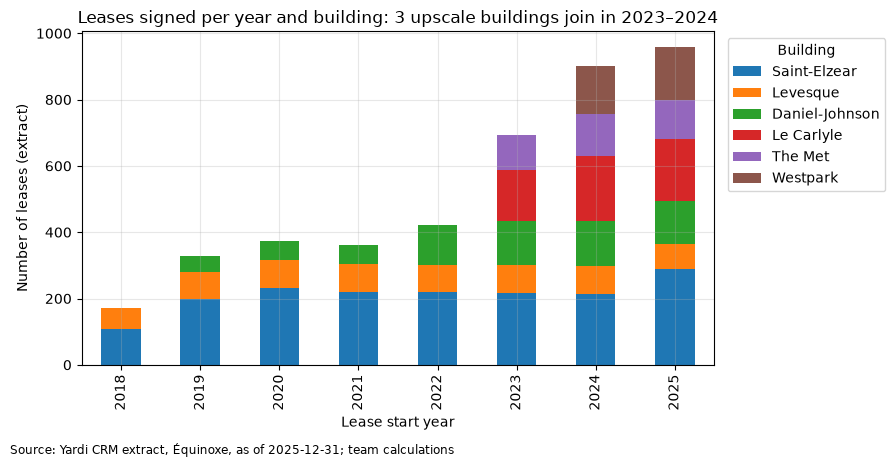

In [16]:
leases_by_building = analysis_leases.pivot_table(index="lease_year", columns="building",
                                                 values="unit_id", aggfunc="size", fill_value=0)
building_order = analysis_leases.groupby("building").lease_year.min().sort_values().index
fig, ax = plt.subplots(figsize=FIGSIZE)
leases_by_building[building_order].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Leases signed per year and building: 3 upscale buildings join in 2023–2024")
ax.set_xlabel("Lease start year")
ax.set_ylabel("Number of leases (extract)")
ax.legend(title="Building", bbox_to_anchor=(1.01, 1), loc="upper left")
add_source(fig)
plt.tight_layout()
plt.show()

### 3.4 Neutralising the building mix
A first fix: compute the change in the median **within each building**, then average it, weighted by the building's
number of leases (only buildings present in both years). This is a first correction; the full method (same apartment) comes in §4.
If the per-building change comes out much smaller than the naive one, then it's new buildings arriving, not prices, that push the median up.

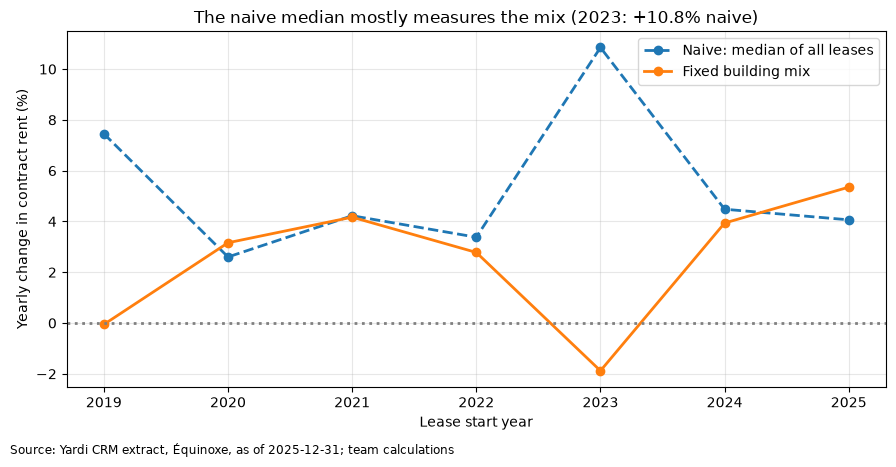

,naive_growth,fixed_building_growth
lease_year,,
2018,NaN,NaN
2019,7.45,-0.06
2020,2.60,3.16
2021,4.23,4.17
2022,3.38,2.78
2023,10.85,-1.88
2024,4.48,3.94
2025,4.06,5.35


In [17]:
building_median = analysis_leases.groupby(["lease_year", "building"]).rent_contract.agg(["median", "size"]).reset_index()
building_median["prev_median"] = building_median.groupby("building")["median"].shift(1)
building_median["prev_year"] = building_median.groupby("building")["lease_year"].shift(1)
comparable = building_median[building_median.prev_year == building_median.lease_year - 1].copy()
comparable["growth"] = comparable["median"] / comparable["prev_median"] - 1
fixed_building_growth = comparable.groupby("lease_year").apply(
    lambda g: np.average(g.growth, weights=g["size"]), include_groups=False)
mix_yearly["fixed_building_growth"] = fixed_building_growth
mix_yearly["naive_growth"] = naive_yearly["naive_growth"]

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(mix_yearly.index, mix_yearly.naive_growth * PCT, "o--", label="Naive: median of all leases")
ax.plot(mix_yearly.index, mix_yearly.fixed_building_growth * PCT, "o-", label="Fixed building mix")
ax.axhline(0, color="grey", linestyle=":")
ax.set_title("The naive median mostly measures the mix (2023: +10.8% naive)")
ax.set_xlabel("Lease start year")
ax.set_ylabel("Yearly change in contract rent (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()
(mix_yearly[["naive_growth", "fixed_building_growth"]] * PCT).round(2)

**Bottom line for §3:** the naive 2023 jump comes from Le Carlyle (2023), The Met (2023) and Westpark (2024) joining:
upscale buildings that rent smaller units at a higher price per sq ft. The units rented get *smaller*
while the median goes *up*. With the building mix held fixed, the 2023 jump disappears. This correction is still noisy (e.g. 2019 and 2023
are negative) because the mix *also* changes *inside* each building (which units get re-let).
So a rent increase has to be measured **apartment by apartment** (§4).

## 4. Comparing each apartment with itself: same-apartment pairs

### 4.1 Matching each lease with the previous lease of the same apartment
We sort the leases by `UNIT_KEY` (`prop_code`, `unit_code`) then by `lease_start`, and attach to each lease
the values of the previous lease **of the same apartment** (`prev_*`). An apartment's first lease has no previous lease, so it is dropped.
Same apartment, same building, same floor area: the only thing left to change is the price. That's the whole idea.

In [18]:
PAIR_CARRY_COLS = ["lease_start", "lease_end", "rent_contract", "rent_effective", "concession_depth"]


def build_lease_pairs(lease_table):
    """Match each lease with the previous lease of the same apartment (key UNIT_KEY).

    Input: renamed lease table. Output: one row per lease that has a previous lease,
    with the prev_* columns and the gap in years between the two lease starts.
    """
    ordered = lease_table.sort_values(UNIT_KEY + ["lease_start"]).copy()
    previous = ordered.groupby(UNIT_KEY)[PAIR_CARRY_COLS].shift(1).add_prefix("prev_")
    candidate_pairs = pd.concat([ordered, previous], axis=1).dropna(subset=["prev_lease_start"])
    candidate_pairs["gap_years"] = (candidate_pairs.lease_start - candidate_pairs.prev_lease_start).dt.days / DAYS_PER_YEAR
    candidate_pairs["days_between_leases"] = (candidate_pairs.lease_start - candidate_pairs.prev_lease_end).dt.days
    return candidate_pairs


candidate_pairs = build_lease_pairs(leases)
print(f"{len(leases):,} leases -> {len(candidate_pairs):,} candidate pairs "
      f"({leases.groupby(UNIT_KEY).ngroups:,} first leases with no previous lease)")
print("Overlaps (previous lease ends after the next one starts):",
      int((candidate_pairs.days_between_leases < 0).sum()))

4,302 leases -> 3,241 candidate pairs (1,061 first leases with no previous lease)
Overlaps (previous lease ends after the next one starts): 0


### 4.2 Which date defines the gap between two leases?
We look at the distribution of the gap between the **starts** of two consecutive leases.
Why the start date? It's the date the new rent takes effect; the start-to-start gap is one year for a
standard renewal. No lease overlaps the next one (checked above), so the chronological order is reliable.

In [19]:
GAP_DISPLAY_BINS = [0, MIN_GAP_YEARS, *GAP_DISPLAY_EDGES, MAX_GAP_YEARS, np.inf]
pd.cut(candidate_pairs.gap_years, GAP_DISPLAY_BINS).value_counts().sort_index().to_frame("pairs")

,pairs
gap_years,
"(0.0, 0.5]",62
"(0.5, 0.9]",10
"(0.9, 1.1]",2789
"(1.1, 1.5]",335
"(1.5, 2.5]",45
"(2.5, inf]",0


### 4.3 Filtering out non-comparable pairs
We keep pairs whose gap is strictly between `MIN_GAP_YEARS` (0.5 year) and `MAX_GAP_YEARS` (2.5 years),
with strictly positive rents.
Why those bounds: under 0.5 year it's usually a short lease or the same lease entered twice (and the annualised change
blows up); over 2.5 years the change mixes several years of market movement.

In [20]:
def filter_comparable_pairs(candidate_pairs, min_gap=MIN_GAP_YEARS, max_gap=MAX_GAP_YEARS):
    """Keep pairs with a gap in ]min_gap, max_gap[ years and positive rents."""
    keep = (candidate_pairs.gap_years.between(min_gap, max_gap, inclusive="neither")
            & (candidate_pairs.prev_rent_contract > 0) & (candidate_pairs.rent_contract > 0))
    return candidate_pairs[keep].copy()


comparable_pairs = filter_comparable_pairs(candidate_pairs)
removed = len(candidate_pairs) - len(comparable_pairs)
print(f"{len(candidate_pairs):,} -> {len(comparable_pairs):,} pairs ({removed} removed, {removed / len(candidate_pairs):.1%})")

3,241 -> 3,179 pairs (62 removed, 1.9%)


### 4.4 Annualising the change
The formula: `growth = (rent / previous rent) ^ (1 / gap_in_years) − 1`, for contract **and** effective rent.
A 6 % increase over 18 months isn't 6 % a year, so we annualise to put every pair on the same footing.

In [21]:
def annualized_growth(current, previous, gap_years):
    """Compound yearly growth rate between two rents gap_years years apart (fraction)."""
    return (current / previous) ** (1 / gap_years) - 1


def add_pair_growth(comparable_pairs):
    """Add growth_contract and growth_effective (annualised fractions)."""
    with_growth = comparable_pairs.copy()
    for basis in ("contract", "effective"):
        with_growth[f"growth_{basis}"] = annualized_growth(
            with_growth[f"rent_{basis}"], with_growth[f"prev_rent_{basis}"], with_growth.gap_years)
    return with_growth


LEASE_PAIR_COLS = ["unit_id", "prop_code", "unit_code", "building", "province", "bedrooms", "lease_year",
                   "lease_type", "is_renewal", "gap_years", "rent_contract", "prev_rent_contract",
                   "rent_effective", "prev_rent_effective", "concession_depth", "prev_concession_depth",
                   "growth_contract", "growth_effective"]
lease_pairs = add_pair_growth(comparable_pairs)[LEASE_PAIR_COLS].reset_index(drop=True)
print(f"{len(lease_pairs):,} pairs over {lease_pairs.unit_id.nunique():,} apartments")

3,179 pairs over 890 apartments


### 4.5 Same-apartment growth per year
The median growth rate per start year of the new lease (the median, so a few odd pairs can't drive it), with the number of pairs `n`.

In [22]:
same_unit_yearly = lease_pairs.groupby("lease_year").agg(
    pairs=("growth_contract", "size"),
    median_contract=("growth_contract", "median"),
    median_effective=("growth_effective", "median"),
    mean_contract=("growth_contract", "mean"),
)
(same_unit_yearly.drop(columns="pairs") * PCT).round(2).assign(pairs=same_unit_yearly.pairs)

,median_contract,median_effective,mean_contract,pairs
lease_year,,,,
2018,2.47,1.98,2.13,88
2019,2.14,1.63,2.00,159
2020,3.17,3.02,3.03,331
2021,4.46,3.54,4.38,355
2022,5.40,4.59,5.27,352
2023,2.29,2.02,2.09,416
2024,3.39,1.77,3.73,698
2025,7.04,3.58,7.56,780


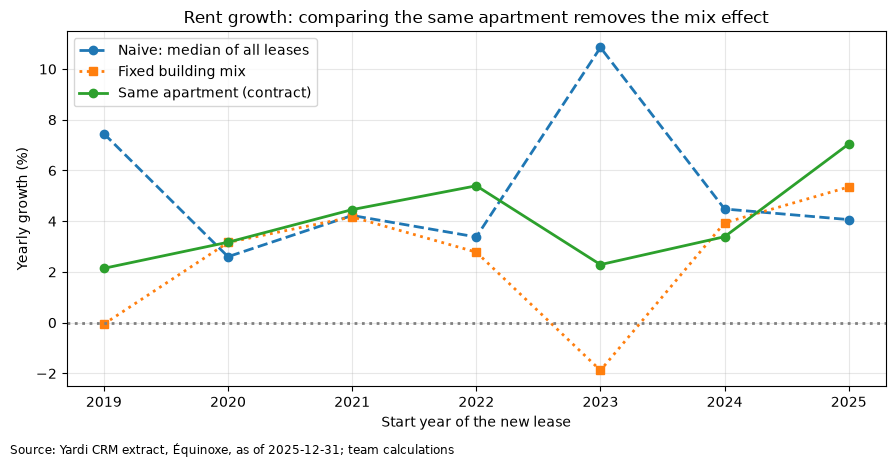

In [23]:
fig, ax = plt.subplots(figsize=FIGSIZE)
years_shown = same_unit_yearly.index[same_unit_yearly.index >= FIRST_ANALYSIS_YEAR + 1]
ax.plot(years_shown, mix_yearly.loc[years_shown, "naive_growth"] * PCT, "o--", label="Naive: median of all leases")
ax.plot(years_shown, mix_yearly.loc[years_shown, "fixed_building_growth"] * PCT, "s:", label="Fixed building mix")
ax.plot(years_shown, same_unit_yearly.loc[years_shown, "median_contract"] * PCT, "o-", label="Same apartment (contract)")
ax.axhline(0, color="grey", linestyle=":")
ax.set_title("Rent growth: comparing the same apartment removes the mix effect")
ax.set_xlabel("Start year of the new lease")
ax.set_ylabel("Yearly growth (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()

### 4.6 Sensitivity to the filtering choices
We recompute the yearly contract median with other gap bounds (`GAP_SENSITIVITY_BOUNDS`) and with the mean instead of the median.
If the answer swung a lot with an arbitrary threshold, we'd have a problem. It barely moves (pairs with a gap of ≈ 1 year are the vast majority).

In [24]:
sensitivity = {}
for min_gap, max_gap in GAP_SENSITIVITY_BOUNDS:
    variant = add_pair_growth(filter_comparable_pairs(candidate_pairs, min_gap, max_gap))
    sensitivity[f"median, gap ]{min_gap}, {max_gap}["] = variant.groupby("lease_year").growth_contract.median()
sensitivity["mean (base bounds)"] = lease_pairs.groupby("lease_year").growth_contract.mean()
(pd.DataFrame(sensitivity).loc[FIRST_ANALYSIS_YEAR:] * PCT).round(2)

,"median, gap ]0.75, 1.5[","median, gap ]0.9, 1.1[","median, gap ]0.5, 2.5[",mean (base bounds)
lease_year,,,,
2018,2.50,2.66,2.47,2.13
2019,2.14,2.27,2.14,2.00
2020,3.20,3.30,3.17,3.03
2021,4.49,4.54,4.46,4.38
2022,5.45,5.55,5.40,5.27
2023,2.30,2.33,2.29,2.09
2024,3.42,3.51,3.39,3.73
2025,7.09,7.13,7.04,7.56


## 5. Concessions: contract rent vs effective rent

### 5.1 How often and how deep concessions are, per year
Per year and lease type: the share of leases with a concession, and the average depth `1 − effective/contract`.
We need both: depth is how much gets given back, frequency is how many leases get something.

In [25]:
concession_by_lease = leases[["unit_id", "lease_year", "province", "lease_type", "has_concession",
                              "rent_contract", "rent_effective", "concession_depth", "term_months"]].copy()
concession_yearly = (concession_by_lease[concession_by_lease.lease_year >= FIRST_ANALYSIS_YEAR]
                     .groupby(["lease_year", "lease_type"])
                     .agg(leases=("has_concession", "size"), share_with_concession=("has_concession", "mean"),
                          mean_depth=("concession_depth", "mean"))
                     .reset_index())
concession_yearly.pivot(index="lease_year", columns="lease_type",
                        values=["share_with_concession", "mean_depth"]).mul(PCT).round(1)

share_with_concession          mean_depth         
lease_type               renewal turnover    renewal turnover
lease_year                                                   
2018                        43.1     36.4        1.6      1.3
2019                        48.5     42.4        1.8      1.6
2020                        47.8     50.0        2.1      2.1
2021                        53.8     54.4        2.7      2.7
2022                        59.9     54.2        3.5      3.1
2023                        47.6     57.9        3.2      3.8
2024                        68.5     77.2        5.4      6.0
2025                        88.6     82.1        9.5      8.8

### 5.2 Which kinds of concessions, and how `PromoPay` looks per month
For each concession start year, the share of leases that receive each code. The one-off credit
(`one_time_promo_credit`) is **spread over the lease** (`amount / term_months`) so it compares with a monthly rent.

In [26]:
lease_terms = leases.groupby(["unit_id", "lease_year"])[["term_months", "rent_contract"]].first()
concessions_by_year = concessions.assign(lease_year=concessions.concession_start.dt.year).join(
    lease_terms, on=["unit_id", "lease_year"], how="inner")
leases_per_year = leases.groupby("lease_year").size()
code_share = (concessions_by_year.groupby(["lease_year", "concession_code"]).unit_id.nunique()
              .unstack().div(leases_per_year, axis=0).loc[FIRST_ANALYSIS_YEAR:DATA_CUTOFF.year])
promo = concessions_by_year[concessions_by_year.concession_code == "one_time_promo_credit"]
promo_monthly_share = (-promo.concession_amount / promo.term_months / promo.rent_contract).groupby(promo.lease_year).median()
print("Promo credit spread over the lease, as % of monthly rent (median):")
print((promo_monthly_share * PCT).round(2).loc[FIRST_ANALYSIS_YEAR:].to_string())
(code_share * PCT).round(1)

Promo credit spread over the lease, as % of monthly rent (median):
lease_year
2018    3.16
2019    3.98
2020    3.64
2021    4.13
2022    4.78
2023    5.87
2024    6.73
2025    7.69


concession_code,Freeothe,Indem,Referenc,freeappl,freelock,freepark,freerent,one_time_promo_credit
lease_year,,,,,,,,
2018,6.4,1.2,1.2,0.6,3.5,9.3,2.9,11.6
2019,7.9,0.9,0.6,0.6,3.4,11.9,1.8,13.7
2020,9.7,1.6,0.5,0.5,2.4,15.3,3.2,23.6
2021,11.1,1.4,0.3,1.1,2.8,15.0,1.9,27.4
2022,11.6,1.2,0.5,0.5,2.6,20.4,3.1,24.2
2023,8.7,1.0,0.6,0.3,4.9,19.0,3.5,22.2
2024,14.4,2.7,1.2,1.3,4.3,25.3,4.9,26.8
2025,16.4,1.1,1.0,1.8,4.8,25.6,4.3,35.1


### 5.3 Contract vs effective growth (same apartment)

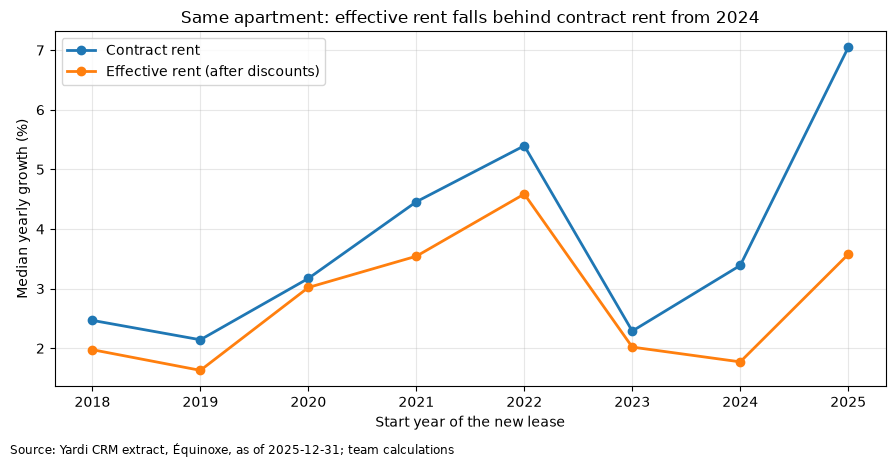

,median_contract,median_effective,mean_prev_depth,mean_depth,gap_pp,pairs
lease_year,,,,,,
2018,2.47,1.98,1.21,1.36,-0.49,88
2019,2.14,1.63,1.36,1.78,-0.51,159
2020,3.17,3.02,1.77,2.07,-0.15,331
2021,4.46,3.54,2.02,2.68,-0.91,355
2022,5.40,4.59,2.74,3.35,-0.81,352
2023,2.29,2.02,3.21,3.24,-0.27,416
2024,3.39,1.77,3.66,5.46,-1.62,698
2025,7.04,3.58,5.79,9.24,-3.47,780


In [27]:
growth_contract_vs_effective = lease_pairs.groupby("lease_year").agg(
    pairs=("growth_contract", "size"),
    median_contract=("growth_contract", "median"),
    median_effective=("growth_effective", "median"),
    mean_prev_depth=("prev_concession_depth", "mean"),
    mean_depth=("concession_depth", "mean"),
)
growth_contract_vs_effective["gap_pp"] = (growth_contract_vs_effective.median_effective
                                          - growth_contract_vs_effective.median_contract)

fig, ax = plt.subplots(figsize=FIGSIZE)
shown = growth_contract_vs_effective.loc[FIRST_ANALYSIS_YEAR:]
ax.plot(shown.index, shown.median_contract * PCT, "o-", label="Contract rent")
ax.plot(shown.index, shown.median_effective * PCT, "o-", label="Effective rent (after discounts)")
ax.set_title("Same apartment: effective rent falls behind contract rent from 2024")
ax.set_xlabel("Start year of the new lease")
ax.set_ylabel("Median yearly growth (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()
(shown.drop(columns="pairs") * PCT).round(2).assign(pairs=shown.pairs)

### 5.4 Why the two growth rates split from 2024
For one pair, this identity is exact:

$$(1+g_{eff}) = (1+g_{contract}) \times \frac{1 - d_{new}}{1 - d_{previous}}$$

where $d$ is the concession depth. When the depth **rises** between the previous lease and the new one, effective growth
falls below contract growth. Below we check that this decomposition reproduces the observed gap.

In [28]:
decomposed = lease_pairs.assign(
    implied_effective=(1 + lease_pairs.growth_contract) ** lease_pairs.gap_years
    * (1 - lease_pairs.concession_depth) / (1 - lease_pairs.prev_concession_depth))
decomposed["implied_effective"] = decomposed.implied_effective ** (1 / decomposed.gap_years) - 1
max_abs_error = (decomposed.implied_effective - decomposed.growth_effective).abs().max()
print(f"Max gap between observed and decomposed effective growth: {max_abs_error:.2e} (exact identity)")

Max gap between observed and decomposed effective growth: 4.44e-16 (exact identity)


**What it means for an owner:**
- Up to 2023, the two curves stay within one point of each other: concessions exist, but their depth barely changes.
- In 2024 and especially 2025, the average **depth** of concessions climbs (about 4 % → 9 % of rent), and nearly every lease gets one.
  Équinoxe posts high contract increases (≈ 7 % in 2025) but gives part of it back (promo credits, free parking):
  the increase actually collected is only about 3.6 %.
- This fits the market: CMHC reports rising vacancy in 2025 and more incentives (free months, bonuses) in big cities (§7).
- **Which one to quote?** For the revenue budget: **effective** (our headline). For renewal notices and the TAL / Ontario rules: **contract**.

## 6. Renewals vs new tenants, and the rules that apply in each province

### 6.1 Four segments: {QC, ON} × {renewal, turnover}
Yearly median growth per province, lease type and basis (contract / effective), with `n`.
The split matters because a renewal (same tenant) is governed by provincial rules; a turnover (new tenant) is priced at market.

In [29]:
growth_by_segment = (lease_pairs
                     .melt(id_vars=["lease_year", "province", "lease_type"],
                           value_vars=["growth_contract", "growth_effective"], var_name="rent_basis", value_name="growth")
                     .assign(rent_basis=lambda d: d.rent_basis.str.replace("growth_", "", regex=False))
                     .groupby(["lease_year", "province", "lease_type", "rent_basis"])
                     .growth.agg(pairs="size", median="median", mean="mean")
                     .reset_index())
segment_view = growth_by_segment[growth_by_segment.lease_year >= FIRST_ANALYSIS_YEAR].pivot_table(
    index="lease_year", columns=["rent_basis", "province", "lease_type"], values="median")
(segment_view * PCT).round(2)

rent_basis contract                           effective                          
province         ON               QC                 ON               QC         
lease_type  renewal turnover renewal turnover   renewal turnover renewal turnover
lease_year                                                                       
2018            NaN      NaN    3.00     1.03       NaN      NaN    2.66     1.03
2019            NaN      NaN    2.55     1.21       NaN      NaN    1.96     1.32
2020            NaN      NaN    3.43     2.05       NaN      NaN    3.28     2.32
2021            NaN      NaN    4.77     3.52       NaN      NaN    4.00     2.36
2022            NaN      NaN    5.69     4.22       NaN      NaN    4.92     3.40
2023            NaN      NaN    2.58     1.85       NaN      NaN    2.21     1.68
2024           2.97     4.94    2.94     4.84      1.33     3.21    1.40     2.52
2025           6.25     8.96    6.43     8.98      2.46     5.45    2.97     5.80

In [30]:
pair_counts = lease_pairs.groupby(["lease_year", "province", "lease_type"]).size().unstack(["province", "lease_type"]).fillna(0).astype(int)
pair_counts.loc[FIRST_ANALYSIS_YEAR:]

province        QC               ON         
lease_type renewal turnover renewal turnover
lease_year                                  
2018            47       41       0        0
2019            92       67       0        0
2020           200      131       0        0
2021           220      135       0        0
2022           226      126       0        0
2023           239      177       0        0
2024           355      235      67       41
2025           410      253      63       54

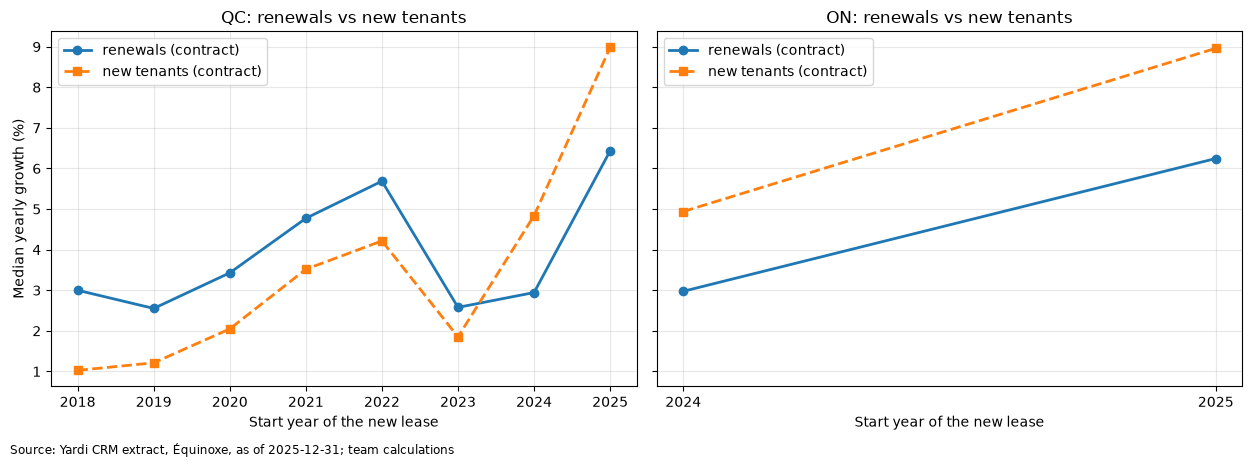

In [31]:
fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE, sharey=True)
for ax, province in zip(axes, ["QC", "ON"]):
    for lease_type, style in [("renewal", "o-"), ("turnover", "s--")]:
        series = growth_by_segment.query("province == @province and lease_type == @lease_type and rent_basis == 'contract'")
        ax.plot(series.lease_year, series["median"] * PCT, style, label=f"{LEASE_TYPE_CHART_LABELS[lease_type]} (contract)")
    ax.set_title(f"{province}: renewals vs new tenants")
    ax.set_xlabel("Start year of the new lease")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # whole years (Ontario only has 2 years)
    ax.legend()
axes[0].set_ylabel("Median yearly growth (%)")
add_source(fig)
plt.tight_layout()
plt.show()

In Québec, renewals lead until 2023 (e.g. 2022: ≈ 5.7 % vs ≈ 4.2 %), then the gap flips:
in 2025, turnovers rise by about 9 % vs ≈ 6.4 % for renewals. The Met (Ontario) only has pairs
from 2024 (first leases in 2023): its history is **thin**. We say so explicitly and only use it
where there are enough pairs (`MIN_PAIRS_PER_SEGMENT_YEAR`).

### 6.2 The applicable rules, phase by phase
We build a `building_regulation` table **per `prop_code`** (one row per building phase), because
age, and therefore section F, differs between phases of the same building (e.g. Saint-Elzéar phase 3 delivered in 2025,
Daniel-Johnson phase 2 in 2022–2023). A table per building would hide these recent phases.

**Year ready for habitation (`ready_year`)**: the construction year is not in the CRM. We take it from public
sources (project pages, checked on 2026-10-04; see `BUILDING_READY_YEAR_PUBLIC` and the *References* section), and we
keep **the earlier** of that year and the first lease year in the extract: a signed lease proves the unit was
already habitable. If no source was found, we keep the first lease year.

**Québec (TAL)**: 5 buildings, 8 phases.
- For renewals, the TAL publishes a reference calculation every year. For 2025: 5.9 % (unheated dwelling, old
  method, official release of 21 January 2025). For 2026: **3.1 %** ("pourcentage de base pour le loyer", new
  method = 3-year average of Québec CPI, published 19 January 2026, so **after** the cutoff date). The two figures
  are not the same series: under the new method, the TAL gives 4.5 % for 2025.
  **It is not a cap**: the landlord can propose more, the tenant can refuse, and the TAL then sets the rent.
- For a new tenant, the lease must state the lowest rent of the past 12 months; the new tenant can contest
  a difference (section G). Turnover rent is therefore close to market, but not completely free.
- **Section F** (art. 1955 C.C.Q.): in a building ready for habitation for 5 years or less, the tenant cannot have
  the TAL set the rent, provided the restriction is written in the lease. **Bill 31 (in force 21 February 2024)**:
  for a lease signed after that date in a building that became habitable after that date, the landlord must also state
  the **maximum rent** they may charge during those 5 years. Here that only concerns Saint-Elzéar phase 3 (2025).
- Consequence for 2026: Le Carlyle (2023), Westpark (2023), Daniel-Johnson phase 2 (2022) and Saint-Elzéar phase 3 (2025)
  are **probably under section F**: their renewals are not brought back to the TAL calculation. Saint-Elzéar 1–2, Lévesque
  and Daniel-Johnson phase 1 are older than 5 years: the TAL calculation is the reference again if a tenant refuses. We can't see the leases
  themselves: "probably" means the age allows it, not proof that the section F box is ticked.

**Ontario (The Met, Ottawa)**:
- The guideline (2.5 % in 2023–2025, 2.1 % in 2026, checked on ontario.ca) caps renewal increases for
  **rent-controlled** units.
- It does not apply to new buildings, additions and most basement units **first occupied for residential purposes
  after 15 November 2018** (ontario.ca). The Met (180 Metcalfe Street) is the former Medical Arts office
  building, extended with a new 28-storey tower and **completed in 2023**. Its units were therefore first
  occupied as homes in 2023, so **The Met is exempt**.
  The data agrees: The Met's renewals ≈ 6.3 % in 2025, well above 2.5 %.
- So we apply neither the TAL nor the guideline to it; we forecast it with its own trend and the Ontario rent CPI.

In [32]:
# Year ready for habitation, from public sources (checked 2026-10-04; links in the References section).
# Documented external data, not a parameter: every value has its source.
BUILDING_READY_YEAR_PUBLIC = {
    "carlyle": 2023,   # delivered 1 July 2023 (guidehabitation.ca; forum.agoramtl.com "Le Carlyle (2023)")
    "levesque": 2019,  # built 2017-2019 (projethabitation.com; forum.agoramtl.com "Équinoxe Lévesque (2019)")
    "dj1": 2020,       # Daniel-Johnson phase 1, built 2018-2020 (guidehabitation.ca)
    "dj2": 2023,       # Daniel-Johnson phase 2, built 2021-2023 (guidehabitation.ca)
    "stelz3": 2025,    # Saint-Elzéar phase 3, occupied April 2025 (guidehabitation.ca)
    "metcalfe": 2023,  # The Met: Medical Arts conversion + 28-storey tower completed 2023 (apartments.com, rentals.ca)
    "wsp1": 2023,      # Westpark: "built in 2023" (rentals.ca, apartments.com)
}
BILL_31_EFFECTIVE_DATE = pd.Timestamp("2024-02-21")  # Bill 31 (QC): maximum rent required under section F after this date

first_lease_year_by_phase = leases.groupby("prop_code").lease_year.min()

building_regulation = (units.groupby(["building", "prop_code", "province"]).size().rename("units").reset_index()
                       .assign(first_lease_year_in_extract=lambda d: d.prop_code.map(first_lease_year_by_phase),
                               ready_year_public=lambda d: d.prop_code.map(BUILDING_READY_YEAR_PUBLIC).astype("Int64")))
# A signed lease proves the unit was habitable: keep the earlier of the two years.
building_regulation["ready_year"] = (building_regulation[["first_lease_year_in_extract", "ready_year_public"]]
                                     .min(axis=1).astype(int))
building_regulation["regime"] = building_regulation.province.map({
    "QC": "TAL (Québec)", "ON": "Residential Tenancies Act, 2006 (Ontario)"})
building_regulation["renewal_reference"] = building_regulation.province.map({
    "QC": "TAL calculation (a reference, not a cap)", "ON": "guideline (a cap if the unit is rent-controlled)"})
qc_section_f = (building_regulation.province == "QC") & (
    FORECAST_YEAR - building_regulation.ready_year <= SECTION_F_WINDOW_YEARS)
on_exempt = (building_regulation.province == "ON") & (
    pd.to_datetime(building_regulation.ready_year.astype(str) + "-01-01") > ONTARIO_EXEMPTION_DATE)
building_regulation["exemption_in_forecast_year"] = np.select(
    [qc_section_f, on_exempt],
    ["Probably section F (ready for habitation ≤ 5 years)",
     "Exempt from the guideline (first residential occupancy after 2018-11-15)"],
    default="none")
# Bill 31: only if the building became habitable after it came into force (the following year, to be safe).
building_regulation["bill_31_max_rent_required"] = qc_section_f & (
    building_regulation.ready_year > BILL_31_EFFECTIVE_DATE.year)
building_regulation["source"] = building_regulation.province.map({
    "QC": "tal.gouv.qc.ca; Civil Code of Québec art. 1955 (section F); Bill 31 (2024)",
    "ON": "ontario.ca/page/rent-increase-guideline; RTA 2006 s. 6.1"})
building_regulation

,building,prop_code,province,units,first_lease_year_in_extract,ready_year_public,ready_year,regime,renewal_reference,exemption_in_forecast_year,bill_31_max_rent_required,source
0,Daniel-Johnson,dj1,QC,58,2019,2020,2019,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
1,Daniel-Johnson,dj2,QC,76,2022,2023,2022,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
2,Le Carlyle,carlyle,QC,192,2023,2023,2023,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
3,Levesque,levesque,QC,84,2018,2019,2018,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
4,Saint-Elzear,stelz1,QC,106,2017,<NA>,2017,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
5,Saint-Elzear,stelz2,QC,122,2019,<NA>,2019,TAL (Québec),"TAL calculation (a reference, not a cap)",none,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
6,Saint-Elzear,stelz3,QC,133,2025,2025,2025,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,True,tal.gouv.qc.ca; Civil Code of Québec art. 1955...
7,The Met,metcalfe,ON,124,2023,2023,2023,"Residential Tenancies Act, 2006 (Ontario)",guideline (a cap if the unit is rent-controlled),Exempt from the guideline (first residential o...,False,ontario.ca/page/rent-increase-guideline; RTA 2...
8,Westpark,wsp1,QC,166,2024,2023,2023,TAL (Québec),"TAL calculation (a reference, not a cap)",Probably section F (ready for habitation ≤ 5 y...,False,tal.gouv.qc.ca; Civil Code of Québec art. 1955...


## 7. External data and reconciliation with the internal trend

### 7.1 Public sources collected (`data/external/`, details in `sources.md`)
| Series | Use | Source |
|---|---|---|
| TAL calculation, unheated dwelling, 2022–2026 | anchor for QC renewals | tal.gouv.qc.ca (official releases) |
| Ontario guideline, 2019–2026 | ON context (The Met exempt, §6.2) | ontario.ca |
| CPI, rent component, QC and ON, monthly (table 18-10-0004-01) | anchor for QC turnovers and Ontario | Statistics Canada |
| CMHC Rental Market Survey 2020–2025 (official tables): **fixed-sample** 2-bedroom rent change, vacancy, turnover premium | alternative anchor (§9.4) + context | CMHC, Rental Market Report data tables |

**No-leakage rule:** to forecast year `Y` as of 31 December `Y−1`, we only use what was published before that date:
CPI up to **November** `Y−1` (released mid-December) and the TAL calculation for `Y−1` (the one for `Y` comes out in January `Y`).
Labelled exception: the central 2026 forecast also uses the 2026 TAL calculation (3.1 %), published in January 2026 (choice explained in §8.5).

### 7.2 Loading and shaping the external series
One row per year × province, every indicator as a fraction.

In [33]:
tal_rates = pd.read_csv(EXTERNAL_DIR / "tal_rent_adjustment.csv")
ontario_guideline = pd.read_csv(EXTERNAL_DIR / "ontario_rent_guideline.csv")
cpi_rent_monthly = pd.read_csv(EXTERNAL_DIR / "statcan_cpi_rent_monthly.csv")
cmhc_official = pd.read_csv(EXTERNAL_DIR / "cmhc_rms_official.csv")

cpi_dates = pd.to_datetime(cpi_rent_monthly.month + "-01")
cpi_rent_monthly["year"] = cpi_dates.dt.year
cpi_rent_monthly["month_num"] = cpi_dates.dt.month
cpi_known = cpi_rent_monthly[cpi_dates <= DATA_CUTOFF]

cpi_annual = (cpi_known.groupby(["geo", "year"]).cpi_rent_index_2002_100.mean()
              .groupby(level="geo").pct_change().rename("cpi_rent_annual"))
cpi_last_known = (cpi_known[cpi_known.month_num == CPI_LAST_KNOWN_MONTH]
                  .set_index(["geo", "year"]).cpi_rent_index_2002_100
                  .groupby(level="geo").pct_change().rename("cpi_rent_nov_yoy"))

external_yearly = pd.concat([cpi_annual, cpi_last_known], axis=1).reset_index().rename(columns={"geo": "province"})
external_yearly = external_yearly.merge(
    tal_rates[["year", "tal_unheated_base_pct"]].assign(province="QC"), on=["province", "year"], how="outer")
external_yearly = external_yearly.merge(
    ontario_guideline[["year", "ontario_guideline_pct"]].assign(province="ON"), on=["province", "year"], how="outer")
external_yearly["tal_rate"] = external_yearly.pop("tal_unheated_base_pct") / PCT
external_yearly["ontario_guideline"] = external_yearly.pop("ontario_guideline_pct") / PCT
# CMHC: fixed-sample 2-bedroom rent change (same "same unit" logic as our measure)
geo_to_province = {geo: province for province, geo in CMHC_GEO_BY_PROVINCE.items()}
cmhc_fixed_sample = (cmhc_official[cmhc_official.metric == "fixed_sample_2br_rent_change"]
                     .assign(province=lambda d: d.geo.map(geo_to_province),
                             cmhc_fixed_sample_2br=lambda d: d.value_pct / PCT)
                     .dropna(subset=["province"])
                     .rename(columns={"survey_year": "year", "published_date": "cmhc_published_date"}))
external_yearly = external_yearly.merge(
    cmhc_fixed_sample[["province", "year", "cmhc_fixed_sample_2br", "cmhc_published_date"]],
    on=["province", "year"], how="left")
external_yearly = external_yearly.sort_values(["province", "year"]).reset_index(drop=True)
(external_yearly.drop(columns="cmhc_published_date").set_index(["province", "year"]).loc[(slice(None), slice(FIRST_ANALYSIS_YEAR, None)), :] * PCT).round(2)

cpi_rent_annual  cpi_rent_nov_yoy  tal_rate  ontario_guideline  cmhc_fixed_sample_2br
province year                                                                                       
ON       2018             1.44              1.60       NaN                NaN                    NaN
         2019             3.80              3.89       NaN                1.8                    NaN
         2020             1.64              1.35       NaN                2.2                    5.2
         2021             1.49              2.28       NaN                0.0                    1.3
         2022             5.58              7.15       NaN                1.2                    4.8
         2023             6.27              5.09       NaN                2.5                    4.0
         2024             6.90              7.37       NaN                2.5                    5.0
         2025             4.30              4.07       NaN                2.5                    3.4
         2026              NaN               NaN       NaN                2.1                    NaN
QC       2018             0.81              1.01       NaN                NaN                    NaN
         2019             1.93              2.34       NaN                NaN                    NaN
         2020             1.20              2.04       NaN                NaN                    3.6
         2021             2.74              1.20       NaN                NaN                    3.9
         2022             3.60              5.30      1.28                NaN                    5.4
         2023             5.88              7.44      2.30                NaN                    7.9
         2024             8.87              8.19      4.00                NaN                    6.3
         2025             7.75              8.28      5.90                NaN                    7.2
         2026              NaN               NaN      3.10                NaN                    NaN

**CMHC market context (never transposed to Équinoxe):** vacancy rate and rent gap between re-let and
not re-let units (2 bedrooms). Vacancy rises in Montréal (1.5 % → 2.9 %) and Ottawa (2.1 % → 3.0 %) between 2023 and 2025.
The market is loosening, which fits with deeper concessions.

In [34]:
cmhc_context = cmhc_official[cmhc_official.metric != "fixed_sample_2br_rent_change"].pivot_table(
    index="survey_year", columns=["metric", "geo"], values="value_pct")
cmhc_context.round(1)

metric      turnover_premium_2br                 vacancy_rate                
geo                       Canada Montreal Ottawa       Canada Montreal Ottawa
survey_year                                                                  
2021                         NaN      NaN    NaN          3.1      3.0    3.4
2022                         NaN      NaN    NaN          1.9      2.0    2.1
2023                         NaN      NaN    NaN          1.5      1.5    2.1
2024                        19.9      9.9   23.2          2.2      2.1    2.6
2025                        16.2      NaN   22.1          3.1      2.9    3.0

### 7.3 Reconciliation: internal trend vs external indicators
For each segment and year, we put our internal contract growth next to the relevant external indicator, and compute the gap.

In [35]:
internal_contract = (growth_by_segment[growth_by_segment.rent_basis == "contract"]
                     .pivot_table(index=["province", "lease_year"], columns="lease_type", values="median")
                     .reset_index().rename(columns={"lease_year": "year"}))
reconciliation = internal_contract.merge(external_yearly, on=["province", "year"], how="left")
reconciliation = reconciliation[reconciliation.year >= FIRST_ANALYSIS_YEAR]
reconciliation["gap_renewal_vs_tal"] = reconciliation.renewal - reconciliation.tal_rate
reconciliation["gap_turnover_vs_cpi"] = reconciliation.turnover - reconciliation.cpi_rent_annual
reconciliation["gap_all_vs_cmhc"] = (reconciliation.renewal + reconciliation.turnover) / 2 - reconciliation.cmhc_fixed_sample_2br
display_cols = ["province", "year", "renewal", "turnover", "tal_rate", "ontario_guideline",
                "cpi_rent_annual", "cmhc_fixed_sample_2br", "gap_renewal_vs_tal", "gap_turnover_vs_cpi", "gap_all_vs_cmhc"]
reconciliation_view = reconciliation[display_cols].set_index(["province", "year"])
(reconciliation_view * PCT).round(2)

renewal  turnover  tal_rate  ontario_guideline  cpi_rent_annual  cmhc_fixed_sample_2br  gap_renewal_vs_tal  gap_turnover_vs_cpi  \
province year                                                                                                                                    
ON       2024     2.97      4.94       NaN                2.5             6.90                    5.0                 NaN                -1.96   
         2025     6.25      8.96       NaN                2.5             4.30                    3.4                 NaN                 4.66   
QC       2018     3.00      1.03       NaN                NaN             0.81                    NaN                 NaN                 0.22   
         2019     2.55      1.21       NaN                NaN             1.93                    NaN                 NaN                -0.72   
         2020     3.43      2.05       NaN                NaN             1.20                    3.6                 NaN                 0.85   
         2021     4.77      3.52       NaN                NaN             2.74                    3.9                 NaN                 0.77   
         2022     5.69      4.22      1.28                NaN             3.60                    5.4                4.41                 0.62   
         2023     2.58      1.85      2.30                NaN             5.88                    7.9                0.28                -4.03   
         2024     2.94      4.84      4.00                NaN             8.87                    6.3               -1.06                -4.04   
         2025     6.43      8.98      5.90                NaN             7.75                    7.2                0.53                 1.23   

               gap_all_vs_cmhc  
province year                   
ON       2024            -1.04  
         2025             4.20  
QC       2018              NaN  
         2019              NaN  
         2020            -0.86  
         2021             0.24  
         2022            -0.45  
         2023            -5.69  
         2024            -2.41  
         2025             0.51

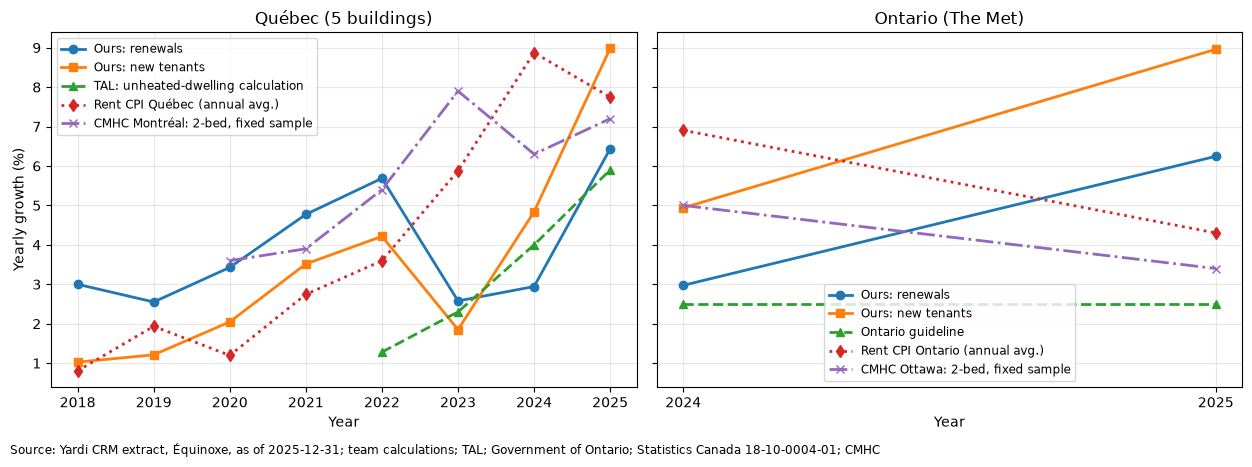

In [36]:
fig, axes = plt.subplots(1, 2, figsize=WIDE_FIGSIZE, sharey=True)
qc = reconciliation[reconciliation.province == "QC"]
axes[0].plot(qc.year, qc.renewal * PCT, "o-", label="Ours: renewals")
axes[0].plot(qc.year, qc.turnover * PCT, "s-", label="Ours: new tenants")
axes[0].plot(qc.year, qc.tal_rate * PCT, "^--", label="TAL: unheated-dwelling calculation")
axes[0].plot(qc.year, qc.cpi_rent_annual * PCT, "d:", label="Rent CPI Québec (annual avg.)")
axes[0].plot(qc.year, qc.cmhc_fixed_sample_2br * PCT, "x-.", label="CMHC Montréal: 2-bed, fixed sample")
axes[0].set_title("Québec (5 buildings)")
on = reconciliation[reconciliation.province == "ON"]
axes[1].plot(on.year, on.renewal * PCT, "o-", label="Ours: renewals")
axes[1].plot(on.year, on.turnover * PCT, "s-", label="Ours: new tenants")
axes[1].plot(on.year, on.ontario_guideline * PCT, "^--", label="Ontario guideline")
axes[1].plot(on.year, on.cpi_rent_annual * PCT, "d:", label="Rent CPI Ontario (annual avg.)")
axes[1].plot(on.year, on.cmhc_fixed_sample_2br * PCT, "x-.", label="CMHC Ottawa: 2-bed, fixed sample")
axes[1].set_title("Ontario (The Met)")
for ax in axes:
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize="small")
axes[0].set_ylabel("Yearly growth (%)")
add_source(fig, SOURCE_CRM + "; TAL; Government of Ontario; Statistics Canada 18-10-0004-01; CMHC")
plt.tight_layout()
plt.show()

### 7.4 What the reconciliation tells us
- **QC renewals vs TAL:** since 2023 the gap is small (≈ ±1 pt: 2023 ≈ 2.6 % vs 2.3 %; 2025 ≈ 6.4 % vs 5.9 %). In 2022 the gap is
  large (≈ 5.7 % vs 1.28 %): the TAL calculation is based on past expenses and reacted late to the inflation shock, while
  landlords were already asking for more. The TAL is therefore a **relevant but non-binding anchor** for renewals.
- **QC turnovers vs QC rent CPI:** turnovers follow the rent CPI with about a one-year lag (CPI 2024 ≈ 8.9 % → turnovers 2025 ≈ 9.0 %).
  That is why the anchor for a turnover in `Y` is the rent CPI known at the end of `Y−1`.
- **Ontario:** The Met's renewals (≈ 3 % in 2024, ≈ 6.3 % in 2025) are above the guideline (2.5 %), which fits the post-2018 exemption.
  So the guideline is **not** used as an anchor; the Ontario rent CPI is.
- **CMHC, fixed sample (2 bedrooms):** Montréal +7.9 % (2023), +6.3 % (2024), +7.2 % (2025); Ottawa +4.0 %, +5.0 %, +3.4 %.
  It is the public measure closest to ours (the same units from one year to the next), and it brackets our turnovers / renewals well.
  Our favourite finding here: the press reported "+10.7 % in Ottawa in 2024", a figure on the average rent of the **whole** stock (new buildings included),
  while the fixed sample gives +5.0 %. **The mix effect from §3 shows up in public statistics too.**
- **CMHC context:** vacancy up in 2025 (Montréal 2.9 %, Ottawa 3.0 %) and a high turnover premium in Ottawa (≈ 22 %):
  a loosening market, which fits concessions staying deep in 2026. Context only, never turned into an occupancy rate for Équinoxe.
- **Indicators we left out:** the guideline for The Met (exempt); CMHC average rents by bedroom count (stock mix, not the same units).

## 8. 2026 forecast: `estimate_2026()`

### 8.1 The method on one page
For each of the 4 segments $s$ = {QC, ON} × {renewal, turnover}, on **contract** rent:

$$g^{contract}_{s,Y} = w \cdot \underbrace{\text{internal trend}_{s}}_{\text{medians of the last 3 years, weighted 1-2-3}} + (1-w)\cdot \underbrace{\text{external anchor}_{s}}_{\text{TAL or rent CPI}}$$

| Segment | External anchor (known on 31 Dec `Y−1`) | Reason |
|---|---|---|
| QC renewal | TAL calculation (unheated) | official reference for renewal increases in Québec |
| QC turnover | Québec rent CPI, Nov `Y−1` over Nov `Y−2` | turnovers follow the market, which follows the rent CPI with a ≈ 1-year lag (§7.4) |
| ON renewal / turnover | Ontario rent CPI, Nov `Y−1` over Nov `Y−2` | The Met is exempt from the guideline (completed 2023, §6.2) |

*Variant tested in §9.4:* replace the rent CPI with the latest CMHC fixed-sample change **published before 1 January `Y`** (Montréal for Québec, Ottawa for Ontario).

Then we move to **effective** rent with the identity from §5.4:
$(1+g^{eff}) = (1+g^{contract}) \cdot \frac{1-d_{Y}}{1-d_{Y-1}}$, with $d_{Y} = d_{Y-1} + \phi\,(d_{Y-1}-d_{Y-2})$:
$\phi$ = share of last year's deepening of concessions that repeats (central 0.5; low 1; high 0).

Finally, segment **weights**: each lease signed in `Y−1` should produce a pair in `Y` (renewal or turnover),
so we weight each province by its `Y−1` leases and split between types using the renewal share observed in `Y−1`.

**Why a simple blend and not XGBoost:** ≈ 3,200 pairs, 3 validation years and a regime change (concessions):
a complex model would overfit the history and couldn't be validated. The blend is transparent, every parameter is named (§0.2)
and `w = 0.5` is fixed **beforehand** (not tuned on the backtest years).

### 8.2 Building blocks of the forecast

In [37]:
def prepare_pairs(lease_table):
    """Full §4 chain: candidate pairs -> gap filter -> annualised growth."""
    return add_pair_growth(filter_comparable_pairs(build_lease_pairs(lease_table)))


def segment_internal_trend(pairs_history, province, lease_type, target_year, window=TREND_WINDOW_YEARS):
    """Weighted average (weights 1, 2, ..., window: most recent = heaviest) of the segment's yearly
    median contract growth over the `window` years before target_year.
    Years with fewer than MIN_PAIRS_PER_SEGMENT_YEAR pairs are skipped.
    Returns (trend, number of pairs used); (nan, 0) if no usable year."""
    in_window = pairs_history[(pairs_history.province == province) & (pairs_history.lease_type == lease_type)
                              & pairs_history.lease_year.between(target_year - window, target_year - 1)]
    yearly = in_window.groupby("lease_year").growth_contract.agg(["median", "size"])
    yearly = yearly[yearly["size"] >= MIN_PAIRS_PER_SEGMENT_YEAR]
    if yearly.empty:
        return np.nan, 0
    recency_weights = yearly.index - (target_year - window - 1)
    return float(np.average(yearly["median"], weights=recency_weights)), int(yearly["size"].sum())


def external_anchor(external, province, lease_type, target_year, use_published_tal,
                    anchor_source=TURNOVER_ANCHOR_SOURCE):
    """External anchor for the segment, using only what was known on 31 December target_year - 1,
    unless use_published_tal=True (TAL calculation for target_year, published in January of target_year).
    anchor_source: "cpi" (rent CPI Nov/Nov) or "cmhc" (latest CMHC fixed-sample change already published)."""
    by_key = external.set_index(["province", "year"])
    if province == "QC" and lease_type == LEASE_TYPE_LABEL[1]:
        tal_year = target_year if use_published_tal else target_year - 1
        return float(by_key.loc[("QC", tal_year), "tal_rate"]), f"TAL {tal_year}"
    if anchor_source == "cmhc":
        published = external[(external.province == province) & external.cmhc_published_date.notna()]
        published = published[pd.to_datetime(published.cmhc_published_date) < pd.Timestamp(f"{target_year}-01-01")]
        latest = published.sort_values("year").iloc[-1]
        return float(latest.cmhc_fixed_sample_2br), f"CMHC {CMHC_GEO_BY_PROVINCE[province]} {int(latest.year)}"
    return float(by_key.loc[(province, target_year - 1), "cpi_rent_nov_yoy"]), f"rent CPI {province} Nov {target_year - 1}"


def concession_depth_path(lease_history, province, lease_type, target_year, persistence):
    """Average concession depth in target_year-1 (d_old) and forecast for target_year (d_new).
    Only leases with rank > 1 (the ones that form pairs). Fallback: province, then portfolio."""
    repeat_leases = lease_history[lease_history.lease_seq > 1]
    candidates = [repeat_leases[(repeat_leases.province == province) & (repeat_leases.lease_type == lease_type)],
                  repeat_leases[repeat_leases.province == province], repeat_leases]
    for subset in candidates:
        yearly = subset.groupby("lease_year").concession_depth.mean()
        if target_year - 1 in yearly.index:
            d_old = yearly[target_year - 1]
            d_before = yearly.get(target_year - 2, d_old)
            d_new = float(np.clip(d_old + persistence * (d_old - d_before), 0, 1 - NUMERIC_TOLERANCE))
            return float(d_old), d_new
    return 0.0, 0.0


def segment_weights(lease_history, pairs_history, target_year):
    """Expected segment weights in target_year: leases signed in target_year-1 per province
    (each will produce a pair), split by the province's renewal share among target_year-1 pairs
    (fallback: portfolio share)."""
    last_year_leases = lease_history[lease_history.lease_year == target_year - 1].groupby("province").size()
    last_year_pairs = pairs_history[pairs_history.lease_year == target_year - 1]
    portfolio_renewal_share = last_year_pairs.is_renewal.mean()
    rows = []
    for province, lease_count in last_year_leases.items():
        province_pairs = last_year_pairs[last_year_pairs.province == province]
        renewal_share = province_pairs.is_renewal.mean() if len(province_pairs) else portfolio_renewal_share
        rows += [(province, LEASE_TYPE_LABEL[1], lease_count * renewal_share),
                 (province, LEASE_TYPE_LABEL[0], lease_count * (1 - renewal_share))]
    weights = pd.DataFrame(rows, columns=SEGMENT_COLS + ["expected_pairs"])
    weights["weight"] = weights.expected_pairs / weights.expected_pairs.sum()
    return weights

### 8.3 Putting together a forecast for any year
The key design choice: `forecast_year()` only uses leases starting **before** 1 January of the target year: the same function
produces the 2026 forecast and the backtest (§9), which guarantees there is no information leakage.

In [38]:
def forecast_from_history(lease_history, pairs_history, external, target_year, w_internal=W_INTERNAL,
                          window=TREND_WINDOW_YEARS, depth_persistence=DEPTH_PERSISTENCE_CENTRAL,
                          use_published_tal=False, anchor_source=TURNOVER_ANCHOR_SOURCE):
    """Per-segment and combined forecast for target_year from an already-truncated history."""
    weights = segment_weights(lease_history, pairs_history, target_year)
    rows = []
    for segment in weights.itertuples():
        trend, trend_pairs = segment_internal_trend(pairs_history, segment.province, segment.lease_type, target_year, window)
        anchor, anchor_label = external_anchor(external, segment.province, segment.lease_type, target_year,
                                               use_published_tal, anchor_source)
        weight_internal = w_internal if trend_pairs else 0.0          # no history -> anchor only
        growth_contract = weight_internal * (trend if trend_pairs else 0.0) + (1 - weight_internal) * anchor
        depth_old, depth_new = concession_depth_path(lease_history, segment.province, segment.lease_type,
                                                     target_year, depth_persistence)
        growth_effective = (1 + growth_contract) * (1 - depth_new) / (1 - depth_old) - 1
        rows.append({"province": segment.province, "lease_type": segment.lease_type, "weight": segment.weight,
                     "internal_trend": trend, "trend_pairs": trend_pairs, "w_internal_used": weight_internal,
                     "external_anchor": anchor, "anchor_source": anchor_label,
                     "depth_last_year": depth_old, "depth_forecast": depth_new,
                     "growth_contract": growth_contract, "growth_effective": growth_effective})
    segments = pd.DataFrame(rows)
    return {"segments": segments,
            "headline_contract": float((segments.weight * segments.growth_contract).sum()),
            "headline_effective": float((segments.weight * segments.growth_effective).sum())}


def forecast_year(lease_table, external, target_year, **options):
    """Cut the leases at lease_start < 1 January target_year, rebuild the pairs and forecast."""
    cutoff = pd.Timestamp(f"{target_year}-01-01")
    lease_history = lease_table[lease_table.lease_start < cutoff]
    return forecast_from_history(lease_history, prepare_pairs(lease_history), external, target_year, **options)

### 8.4 Uncertainty: bootstrapping the pairs
We resample the historical pairs `N_BOOTSTRAP` times (with replacement, within each segment × year),
recompute the forecast and keep the 80 % interval. This interval only captures the sampling noise of the internal trend;
uncertainty about concessions is handled separately by the low / high scenarios.

In [39]:
def bootstrap_headline(lease_table, external, target_year, n_draws=N_BOOTSTRAP, seed=RANDOM_SEED, **options):
    """Bootstrap distribution of the combined forecast (effective and contract)."""
    rng = np.random.default_rng(seed)
    cutoff = pd.Timestamp(f"{target_year}-01-01")
    lease_history = lease_table[lease_table.lease_start < cutoff]
    pairs_history = prepare_pairs(lease_history)
    groups = [g.index.to_numpy() for _, g in pairs_history.groupby(["province", "lease_type", "lease_year"])]
    draws = []
    for _ in range(n_draws):
        sampled_index = np.concatenate([rng.choice(idx, size=len(idx), replace=True) for idx in groups])
        result = forecast_from_history(lease_history, pairs_history.loc[sampled_index], external, target_year, **options)
        draws.append((result["headline_effective"], result["headline_contract"]))
    return pd.DataFrame(draws, columns=["headline_effective", "headline_contract"])

### 8.5 `estimate_2026()`
**Interface:** keeps the template's signature (`leases`, `asking`, `external`). `asking` is not used in the forecast:
advertised rents move with turnovers in the same year (they don't lead them), so they add no extra information
on 31 December; we document this instead of forcing them in.
**Labelled choice:** the central forecast uses the 2026 TAL calculation (3.1 %), published in January 2026, after the data date
(`use_published_tal=True`); the strict variant (TAL 2025) is reported next to it.

In [40]:
def estimate_2026(leases, asking=None, external=None, run_bootstrap=True):
    """2026 forecast of HEUC (same-apartment effective increase, portfolio) and HCUC (contract).

    Returns a dict: headline figures (fractions), per-segment table, scenarios, bootstrap interval,
    strict variant, definition, method and assumptions. `asking` is accepted but not used (see §8.5).
    """
    external = external_yearly if external is None else external
    central = forecast_year(leases, external, FORECAST_YEAR, use_published_tal=True)
    scenarios = {
        name: forecast_year(leases, external, FORECAST_YEAR, use_published_tal=True, depth_persistence=persistence)
        for name, persistence in [("low", DEPTH_PERSISTENCE_LOW), ("central", DEPTH_PERSISTENCE_CENTRAL),
                                  ("high", DEPTH_PERSISTENCE_HIGH)]}
    strict = forecast_year(leases, external, FORECAST_YEAR, use_published_tal=False)
    interval = None
    if run_bootstrap:
        draws = bootstrap_headline(leases, external, FORECAST_YEAR, use_published_tal=True)
        interval = draws.quantile(list(BOOTSTRAP_QUANTILES)).to_dict()
    return {
        "definition": "HEUC-2026: median annualised growth of effective rent between two consecutive leases of the same "
                      "apartment (sPropCode + sUnitCode), leases starting in 2026, 4 segments {QC, ON} x {renewal, "
                      "turnover} weighted by their expected number of pairs.",
        "headline_effective": central["headline_effective"],
        "headline_contract": central["headline_contract"],
        "segments": central["segments"],
        "scenarios": {name: {"effective": r["headline_effective"], "contract": r["headline_contract"]}
                      for name, r in scenarios.items()},
        "strict_as_of_cutoff": {"effective": strict["headline_effective"], "contract": strict["headline_contract"]},
        "bootstrap_interval_80": interval,
        "method": f"w={W_INTERNAL} x internal trend ({TREND_WINDOW_YEARS} years, recent years weigh more) + (1-w) x external anchor; "
                  f"converted to effective rent with the concession depth (persistence {DEPTH_PERSISTENCE_CENTRAL}).",
        "assumptions": [
            "Each segment moves in 2026 like the blend of its internal trend and its external anchor.",
            "TAL 2026 calculation = 3.1% (published January 2026, after the data date: labelled choice).",
            "The Met is exempt from Ontario's guideline (first occupied after 15 Nov 2018).",
            "Half of the 2025 deepening of concessions repeats in 2026 (low/high scenarios: all of it / none of it).",
            "Each province's renewal share stays at its 2025 level.",
        ],
    }


forecast_result = estimate_2026(leases, external=external_yearly)
print(f"HEUC-2026 (effective, central) : {forecast_result['headline_effective'] * PCT:.2f} %")
print(f"HCUC-2026 (contract)           : {forecast_result['headline_contract'] * PCT:.2f} %")
forecast_2026 = forecast_result["segments"]
display_segments = forecast_2026.copy()
pct_cols = ["weight", "internal_trend", "w_internal_used", "external_anchor", "depth_last_year", "depth_forecast",
            "growth_contract", "growth_effective"]
display_segments[pct_cols] = (display_segments[pct_cols] * PCT).round(2)
display_segments

HEUC-2026 (effective, central) : 2.96 %
HCUC-2026 (contract)           : 5.18 %


,province,lease_type,weight,internal_trend,trend_pairs,w_internal_used,external_anchor,anchor_source,depth_last_year,depth_forecast,growth_contract,growth_effective
0,ON,renewal,6.74,4.94,130,50.0,4.07,rent CPI ON Nov 2025,10.52,12.47,4.50,2.23
1,ON,turnover,5.78,7.35,95,50.0,4.07,rent CPI ON Nov 2025,10.14,12.38,5.71,3.07
2,QC,renewal,54.09,4.63,1004,50.0,3.10,TAL 2026,9.29,11.38,3.86,1.47
3,QC,turnover,33.38,6.41,665,50.0,8.28,rent CPI QC Nov 2025,8.72,10.31,7.35,5.48


### 8.6 Saving the model parameters (`models/forecast_params.json`)
We write every parameter and aggregated output (no raw CRM data) so the figure can be reproduced.

In [41]:
forecast_params = {
    "forecast_year": FORECAST_YEAR, "data_cutoff": str(DATA_CUTOFF.date()),
    "definition": forecast_result["definition"], "method": forecast_result["method"],
    "constants": {"W_INTERNAL": W_INTERNAL, "TREND_WINDOW_YEARS": TREND_WINDOW_YEARS,
                  "MIN_PAIRS_PER_SEGMENT_YEAR": MIN_PAIRS_PER_SEGMENT_YEAR, "MIN_GAP_YEARS": MIN_GAP_YEARS,
                  "MAX_GAP_YEARS": MAX_GAP_YEARS, "DEPTH_PERSISTENCE_CENTRAL": DEPTH_PERSISTENCE_CENTRAL,
                  "DEPTH_PERSISTENCE_LOW": DEPTH_PERSISTENCE_LOW, "DEPTH_PERSISTENCE_HIGH": DEPTH_PERSISTENCE_HIGH,
                  "N_BOOTSTRAP": N_BOOTSTRAP, "RANDOM_SEED": RANDOM_SEED},
    "segments": forecast_2026.round(6).to_dict(orient="records"),
    "headline_effective": round(forecast_result["headline_effective"], 6),
    "headline_contract": round(forecast_result["headline_contract"], 6),
    "scenarios": forecast_result["scenarios"],
    "strict_as_of_cutoff": forecast_result["strict_as_of_cutoff"],
    "bootstrap_interval_80": forecast_result["bootstrap_interval_80"],
    "assumptions": forecast_result["assumptions"],
}
(MODELS_DIR / "forecast_params.json").write_text(json.dumps(forecast_params, indent=2, ensure_ascii=False, default=float),
                                                 encoding="utf-8")
print("Wrote:", (MODELS_DIR / "forecast_params.json").relative_to(PROJECT_ROOT))

Wrote: models\forecast_params.json


## 9. Backtest: would the method have predicted 2023, 2024 and 2025 well?

### 9.1 How it works
For each year `Y`: we stand on 31 December `Y−1`, keep only leases starting before 1 January `Y`
and external data published before that date (CPI up to November `Y−1`, TAL calculation for `Y−1`), forecast `Y`
with **exactly** the same function, then compare with the HEUC / HCUC actually observed in `Y`.
The parameters (`W_INTERNAL`, `TREND_WINDOW_YEARS`, persistence) are the ones fixed beforehand in §0.2: they were **not** tuned on these years.

In [42]:
def observed_headline(pairs, target_year):
    """Observed HEUC / HCUC: median per segment, weighted by the year's number of pairs."""
    year_pairs = pairs[pairs.lease_year == target_year]
    by_segment = year_pairs.groupby(SEGMENT_COLS).agg(pairs=("growth_contract", "size"),
                                                      median_contract=("growth_contract", "median"),
                                                      median_effective=("growth_effective", "median"))
    weight = by_segment.pairs / by_segment.pairs.sum()
    return {"contract": float((weight * by_segment.median_contract).sum()),
            "effective": float((weight * by_segment.median_effective).sum()),
            "segments": by_segment.reset_index()}


def backtest(leases, target_year, external=None, **options):
    """Run the method as of 31 December target_year - 1 and compare with what happened in target_year.
    Returns a dict with forecast / actual / errors (percentage points, as fractions) and the per-segment detail."""
    external = external_yearly if external is None else external
    predicted = forecast_year(leases, external, target_year, **options)
    actual = observed_headline(prepare_pairs(leases), target_year)
    return {"year": target_year,
            "predicted_effective": predicted["headline_effective"], "actual_effective": actual["effective"],
            "predicted_contract": predicted["headline_contract"], "actual_contract": actual["contract"],
            "error_effective": predicted["headline_effective"] - actual["effective"],
            "error_contract": predicted["headline_contract"] - actual["contract"],
            "predicted_segments": predicted["segments"], "actual_segments": actual["segments"]}


backtest_runs = {year: backtest(leases, year) for year in BACKTEST_YEARS}
backtest_results = pd.DataFrame([{k: v for k, v in run.items() if not k.endswith("segments")}
                                 for run in backtest_runs.values()]).set_index("year")
(backtest_results * PCT).round(2)

,predicted_effective,actual_effective,predicted_contract,actual_contract,error_effective,error_contract
year,,,,,,
2023,3.26,1.99,3.62,2.27,1.27,1.35
2024,4.23,1.88,4.17,3.70,2.35,0.47
2025,3.72,4.02,4.70,7.42,-0.30,-2.72


### 9.2 Error metrics
**MAE** (mean absolute error), **RMSE** and **bias** (mean signed error), in percentage points.

In [43]:
def error_metrics(errors):
    """MAE, RMSE and bias of a series of errors (fractions)."""
    return pd.Series({"MAE": errors.abs().mean(), "RMSE": np.sqrt((errors ** 2).mean()), "bias": errors.mean()})


backtest_metrics = pd.DataFrame({"effective (HEUC)": error_metrics(backtest_results.error_effective),
                                 "contract (HCUC)": error_metrics(backtest_results.error_contract)})
(backtest_metrics * PCT).round(2)

,effective (HEUC),contract (HCUC)
MAE,1.31,1.51
RMSE,1.55,1.77
bias,1.11,-0.30


### 9.2b Detail by segment
Forecast vs actual for each of the 4 segments, to see where the errors come from.

In [44]:
segment_frames = []
for year, run in backtest_runs.items():
    predicted = run["predicted_segments"].set_index(SEGMENT_COLS)[["growth_effective", "growth_contract"]].add_prefix("predicted_")
    observed = run["actual_segments"].set_index(SEGMENT_COLS)
    segment_frames.append(predicted.join(observed, how="outer").assign(year=year))
segment_backtest = pd.concat(segment_frames).reset_index().set_index(["year"] + SEGMENT_COLS)
segment_backtest["error_effective"] = segment_backtest.predicted_growth_effective - segment_backtest.median_effective
pct_cols = [c for c in segment_backtest.columns if c != "pairs"]
(segment_backtest[pct_cols] * PCT).round(2).assign(pairs=segment_backtest.pairs)

predicted_growth_effective  predicted_growth_contract  median_contract  median_effective  error_effective  pairs
year province lease_type                                                                                                                  
2023 QC       renewal                           2.72                       3.14             2.58              2.21             0.50    239
              turnover                          4.22                       4.46             1.85              1.68             2.54    177
2024 ON       renewal                           5.17                       5.09             2.97              1.33             3.83     67
              turnover                          5.17                       5.09             4.94              3.21             1.95     41
     QC       renewal                           3.33                       3.14             2.94              1.40             1.93    355
              turnover                          5.06                       5.18             4.84              2.52             2.54    235
2025 ON       renewal                           5.17                       5.17             6.25              2.46             2.71     63
              turnover                          6.16                       6.16             8.96              5.45             0.71     54
     QC       renewal                           2.57                       3.64             6.43              2.97            -0.40    410
              turnover                          4.71                       5.96             8.98              5.80            -1.10    253

### 9.3 Comparison with reference methods
Would something simpler have done just as well? Same exercise, four simpler methods:
1. **Persistence**: forecast `Y` = value observed in `Y−1`;
2. **External anchor only** (`w = 0`);
3. **Internal trend only** (`w = 1`);
4. **Naive median**: change in the median of all leases in `Y−1` (distorted by the mix, §3).

In [45]:
all_pairs = prepare_pairs(leases)
naive_median = leases.groupby("lease_year").rent_contract.median().pct_change()
baseline_rows = []
for year in BACKTEST_YEARS:
    actual = observed_headline(all_pairs, year)
    previous = observed_headline(all_pairs, year - 1)
    anchor_only = forecast_year(leases, external_yearly, year, w_internal=0.0)
    internal_only = forecast_year(leases, external_yearly, year, w_internal=1.0)
    baseline_rows.append({
        "year": year,
        "our method": backtest_runs[year]["error_effective"],
        "persistence": previous["effective"] - actual["effective"],
        "external anchor only": anchor_only["headline_effective"] - actual["effective"],
        "internal trend only": internal_only["headline_effective"] - actual["effective"],
        "naive median": naive_median[year - 1] - actual["effective"],
    })
baseline_errors = pd.DataFrame(baseline_rows).set_index("year")
baseline_summary = pd.concat([baseline_errors, baseline_errors.abs().mean().rename("MAE").to_frame().T])
(baseline_summary * PCT).round(2)

,our method,persistence,external anchor only,internal trend only,naive median
2023,1.27,2.39,0.38,2.16,1.39
2024,2.35,0.11,2.76,1.95,8.97
2025,-0.30,-2.15,0.90,-1.49,0.46
MAE,1.31,1.55,1.35,1.87,3.61


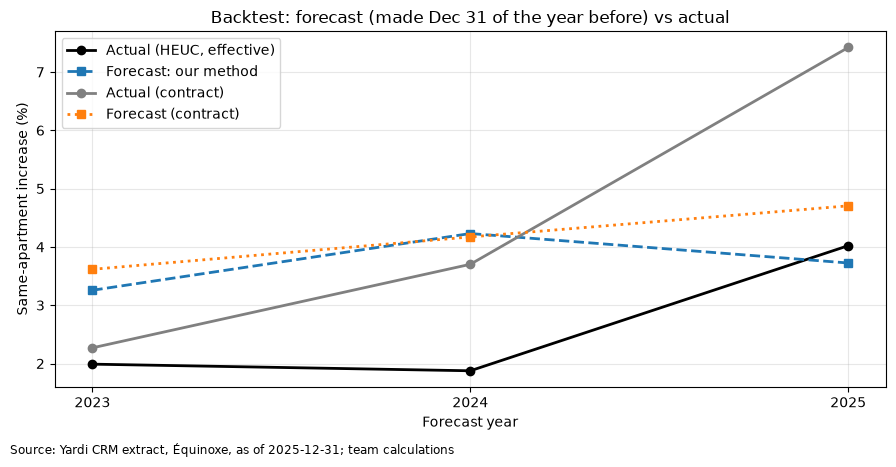

In [46]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(backtest_results.index, backtest_results.actual_effective * PCT, "o-", color="black", label="Actual (HEUC, effective)")
ax.plot(backtest_results.index, backtest_results.predicted_effective * PCT, "s--", label="Forecast: our method")
ax.plot(backtest_results.index, backtest_results.actual_contract * PCT, "o-", color="grey", label="Actual (contract)")
ax.plot(backtest_results.index, backtest_results.predicted_contract * PCT, "s:", label="Forecast (contract)")
ax.set_xticks(list(BACKTEST_YEARS))
ax.set_title("Backtest: forecast (made Dec 31 of the year before) vs actual")
ax.set_xlabel("Forecast year")
ax.set_ylabel("Same-apartment increase (%)")
ax.legend()
add_source(fig)
plt.tight_layout()
plt.show()

### 9.4 Sensitivity to the parameters (read-only, no tuning)
Backtest effective MAE for other values of `w` and of the window, and for the two extreme concession assumptions.
**Careful:** picking the best combination here and then "validating" it on the same 3 years would be overfitting; this table shows
robustness, it is not used to choose. The "published TAL" variant shows what the target year's TAL calculation adds (not available on 31 December).

In [47]:
sensitivity_rows = []
for w_value in SENSITIVITY_W_VALUES:
    for window in SENSITIVITY_WINDOWS:
        for persistence in (DEPTH_PERSISTENCE_HIGH, DEPTH_PERSISTENCE_CENTRAL, DEPTH_PERSISTENCE_LOW):
            for use_tal in (False, True):
                errors = [backtest(leases, year, w_internal=w_value, window=window, depth_persistence=persistence,
                                   use_published_tal=use_tal)["error_effective"] for year in BACKTEST_YEARS]
                sensitivity_rows.append({"w_internal": w_value, "window": window, "depth_persistence": persistence,
                                         "published_tal": use_tal, "MAE_effective_pct": np.mean(np.abs(errors)) * PCT})
parameter_sensitivity = pd.DataFrame(sensitivity_rows)
parameter_sensitivity.pivot_table(index=["w_internal", "window"], columns=["published_tal", "depth_persistence"],
                                  values="MAE_effective_pct").round(2)

published_tal     False             True             
depth_persistence   0.0   0.5   1.0   0.0   0.5   1.0
w_internal window                                    
0.00       1       1.78  1.35  0.98  2.60  2.16  1.73
           2       1.78  1.35  0.98  2.60  2.16  1.73
           3       1.78  1.35  0.98  2.60  2.16  1.73
0.25       1       1.64  1.21  1.20  2.25  1.82  1.39
           2       1.65  1.22  1.28  2.26  1.83  1.41
           3       1.66  1.23  1.25  2.27  1.84  1.41
0.50       1       1.50  1.20  1.43  1.91  1.48  1.52
           2       1.52  1.35  1.58  1.93  1.50  1.67
           3       1.54  1.31  1.53  1.95  1.52  1.62
0.75       1       1.36  1.43  1.65  1.57  1.47  1.70
           2       1.43  1.66  1.88  1.59  1.70  1.92
           3       1.42  1.59  1.81  1.62  1.63  1.85
1.00       1       1.44  1.66  1.88  1.44  1.66  1.88
           2       1.74  1.96  2.18  1.74  1.96  2.18
           3       1.64  1.87  2.09  1.64  1.87  2.09

### 9.4b Choosing `w` by leave-one-year-out cross-validation
For each backtest year, pick `w` from the grid looking **only at the other two years**,
then measure the error on the held-out year. If we wanted to choose `w` from the data, this is the only fair way to do it.
Limit: with 3 years, a "training" year can come after the year being scored; we flag it.

In [48]:
def backtest_mae(years, **options):
    """Backtest effective MAE (fraction) over the given years."""
    return float(np.mean([abs(backtest(leases, year, **options)["error_effective"]) for year in years]))


loyo_rows = []
for held_out in BACKTEST_YEARS:
    training_years = [year for year in BACKTEST_YEARS if year != held_out]
    best_w = min(SENSITIVITY_W_VALUES, key=lambda w_value: backtest_mae(training_years, w_internal=w_value))
    loyo_rows.append({"held-out year": held_out, "w chosen (on the other 2)": best_w,
                      "error with chosen w (pt)": backtest(leases, held_out, w_internal=best_w)["error_effective"] * PCT,
                      "error with w = W_INTERNAL (pt)": backtest_runs[held_out]["error_effective"] * PCT})
loyo_results = pd.DataFrame(loyo_rows).set_index("held-out year")
print(f"Cross-validation MAE: {loyo_results['error with chosen w (pt)'].abs().mean():.2f} pt "
      f"vs {loyo_results['error with w = W_INTERNAL (pt)'].abs().mean():.2f} pt with w fixed beforehand")
loyo_results.round(2)

Cross-validation MAE: 1.57 pt vs 1.31 pt with w fixed beforehand


,w chosen (on the other 2),error with chosen w (pt),error with w = W_INTERNAL (pt)
held-out year,,,
2023,0.50,1.27,1.27
2024,0.25,2.56,2.35
2025,0.00,0.90,-0.30


### 9.4c Rent-CPI anchor vs CMHC (fixed-sample) anchor
Same backtest, but with the other anchor for QC turnovers and Ontario. For year `Y`, we only use
the CMHC edition **published before 1 January `Y`**: for example, the 2023 survey came out in late January 2024, so it is not used to forecast 2024.

In [49]:
anchor_errors = pd.DataFrame({source: [backtest(leases, year, anchor_source=source)["error_effective"] for year in BACKTEST_YEARS]
                              for source in ("cpi", "cmhc")}, index=list(BACKTEST_YEARS))
anchor_errors.loc["MAE"] = anchor_errors.abs().mean()
anchor_2026 = {source: forecast_year(leases, external_yearly, FORECAST_YEAR, use_published_tal=True,
                                     anchor_source=source)["headline_effective"] for source in ("cpi", "cmhc")}
print("HEUC-2026 by anchor:", {k: f"{v * PCT:.2f} %" for k, v in anchor_2026.items()})
(anchor_errors * PCT).round(2)

HEUC-2026 by anchor: {'cpi': '2.96 %', 'cmhc': '2.74 %'}


,cpi,cmhc
2023,1.27,1.02
2024,2.35,1.94
2025,-0.30,-0.78
MAE,1.31,1.25


### 9.4d Appendix: a simple regression as a point of comparison
A linear regression of each year's observed HEUC on the Québec rent CPI known at the end of `Y−1`,
estimated only on years before `Y` (expanding window), then used to forecast `Y`.
The question: would a "classic" statistical model beat our transparent blend? With 4 to 6 training points this model is fragile; it is a comparison, not an alternative we adopt.

In [50]:
headline_by_year = pd.Series({year: observed_headline(all_pairs, year)["effective"]
                              for year in range(FIRST_ANALYSIS_YEAR, DATA_CUTOFF.year + 1)})
qc_cpi_known = external_yearly[external_yearly.province == "QC"].set_index("year").cpi_rent_nov_yoy
regression_rows = []
for year in BACKTEST_YEARS:
    train_years = [t for t in headline_by_year.index if t < year and (t - 1) in qc_cpi_known.dropna().index]
    design = np.column_stack([np.ones(len(train_years)), qc_cpi_known.loc[[t - 1 for t in train_years]]])
    coefficients, *_ = np.linalg.lstsq(design, headline_by_year.loc[train_years].to_numpy(), rcond=None)
    predicted = coefficients[0] + coefficients[1] * qc_cpi_known.loc[year - 1]
    regression_rows.append({"year": year, "training_points": len(train_years),
                            "regression_error": predicted - headline_by_year[year],
                            "our_method_error": backtest_runs[year]["error_effective"]})
regression_check = pd.DataFrame(regression_rows).set_index("year")
regression_check.loc["MAE"] = regression_check.abs().mean()
regression_check[["regression_error", "our_method_error"]] = regression_check[["regression_error", "our_method_error"]] * PCT
regression_check.round(2)

,training_points,regression_error,our_method_error
year,,,
2023,5.0,3.21,1.27
2024,6.0,0.26,2.35
2025,7.0,-2.17,-0.30
MAE,6.0,1.88,1.31


### 9.5 What the backtest tells us
- The backtest only has **3 years**: each error weighs a lot, and 2024 is the year concessions jumped,
  which no method based on the past could fully anticipate.
- Ontario only enters from 2024, with no internal history (anchor only): the backtest is **thin** for The Met.
- **Result (parameters fixed beforehand):** effective MAE ≈ 1.3 pt, better on average than persistence (≈ 1.6), the internal trend alone (≈ 1.9)
  and the naive median (≈ 3.6), and only just better than the external anchor alone (≈ 1.35). It does **not win every year**:
  in 2024 it overestimates (+2.3 pts) because the sudden deepening of concessions wasn't visible at the end of 2023.
- **Positive bias** (≈ +1.1 pt): the method has tended to overestimate the effective increase, one more reason to show the low scenario.
- The **published** TAL calculation for the target year does not improve the backtest (higher MAE in table 9.4): the TAL follows past costs,
  not the increases actually agreed. We still use it for 2026, because the TAL method changed in 2026 (3.1 % vs 5.9 % in 2025)
  and ignoring a known regulatory change would be harder to defend; the strict variant is always shown next to it.
- **By segment (9.2b):** the biggest error comes from The Met in 2024 (renewals: 5.2 % forecast, 1.3 % actual), with no internal history:
  the Ontario rent-CPI anchor alone overestimated. In Québec, the 2024 errors mostly come from concessions (effective well below contract).
- **Choosing `w` from the data doesn't help (9.4b):** with cross-validation, MAE ≈ 1.6 pt vs ≈ 1.3 pt for `w = 0.5` fixed beforehand. We keep 0.5.
- **CMHC vs CPI anchor (9.4c):** almost the same MAE (≈ 1.25 vs 1.31 pt) and HEUC-2026 of 2.7 % instead of 3.0 %: the conclusion doesn't depend on this choice.
  We keep the CPI (monthly series, available earlier and consistently for both provinces).
- **Simple regression (9.4d):** MAE ≈ 1.9 pt, worse and very unstable (5 to 7 training points).

## 10. Results

### 10.1 The final figure

In [51]:
scenario_table = pd.DataFrame(forecast_result["scenarios"]).T[["effective", "contract"]]
scenario_table.loc["strict (TAL 2025, info as of 31 Dec 2025)"] = pd.Series(forecast_result["strict_as_of_cutoff"])
interval = forecast_result["bootstrap_interval_80"]
print(f"HEUC-2026 = {forecast_result['headline_effective'] * PCT:.1f} %  "
      f"(same-apartment effective increase, portfolio, leases starting in 2026)")
print(f"   low / central / high (concessions): "
      + " / ".join(f"{forecast_result['scenarios'][s]['effective'] * PCT:.1f} %" for s in ("low", "central", "high")))
if interval:
    low_q, high_q = BOOTSTRAP_QUANTILES
    print(f"   80 % bootstrap interval: {interval['headline_effective'][low_q] * PCT:.1f} % to "
          f"{interval['headline_effective'][high_q] * PCT:.1f} %")
typical_error = backtest_metrics.loc["MAE", "effective (HEUC)"]
print(f"   typical backtest error (MAE 2023-2025): ± {typical_error * PCT:.1f} pt")
print(f"HCUC-2026 (contract) = {forecast_result['headline_contract'] * PCT:.1f} %")
(scenario_table * PCT).round(2)

HEUC-2026 = 3.0 %  (same-apartment effective increase, portfolio, leases starting in 2026)
   low / central / high (concessions): 0.7 % / 3.0 % / 5.2 %
   80 % bootstrap interval: 2.9 % to 3.0 %
   typical backtest error (MAE 2023-2025): ± 1.3 pt
HCUC-2026 (contract) = 5.2 %


,effective,contract
low,0.74,5.18
central,2.96,5.18
high,5.18,5.18
"strict (TAL 2025, info as of 31 Dec 2025)",3.70,5.93


**Reading the uncertainty:** the bootstrap interval is narrow because it only measures the sampling noise of the
medians (hundreds of pairs per segment). The real sources of uncertainty are (1) the depth of concessions in 2026
(low / high scenarios) and (2) the method error, measured by the backtest (± MAE). That is the range we present to the jury.

**Definition (reminder of §1):** HEUC-2026 = segment-weighted average of the medians of annualised growth in **effective rent**
between two consecutive leases of the **same apartment** (`sPropCode + sUnitCode`), for leases starting in 2026, over
{QC, ON} × {renewal, turnover}. The Met is treated under Ontario's rules (exempt from the guideline), the other 5
buildings under the TAL regime.

### 10.2 Assumptions
1. Each segment moves like a 50/50 blend of its recent trend and its public anchor (TAL or rent CPI).
2. TAL 2026 calculation = 3.1 % (published after the data date: labelled choice; strict variant above).
3. The Met: units first occupied after 15 November 2018, so the guideline doesn't apply.
4. Concessions: half of the deepening seen in 2025 repeats in 2026 (low scenario: all of it; high: none).
5. Each province's renewal / turnover split stays as in 2025.

### 10.3 Bonus: by building and number of bedrooms
In 2025, median growth is almost the same from one building to the next (table below):
nothing justifies a separate trend for each building. So the forecast for a building × bedrooms cell combines its province's
segment forecasts using **its own** 2025 renewal share (falling back on the province if the cell has fewer than
`MIN_PAIRS_PER_CELL` pairs).

In [52]:
last_year = FORECAST_YEAR - 1
recent_pairs = all_pairs[all_pairs.lease_year == last_year]
building_check = recent_pairs.groupby("building").agg(pairs=("growth_contract", "size"),
                                                      median_contract=("growth_contract", "median"),
                                                      median_effective=("growth_effective", "median"))
display((building_check[["median_contract", "median_effective"]] * PCT).round(2).assign(pairs=building_check.pairs))

segment_forecast = forecast_2026.set_index(SEGMENT_COLS)
province_renewal_share = recent_pairs.groupby("province").is_renewal.mean()
cell_rows = []
for (building, province, bedrooms), cell in recent_pairs.groupby(["building", "province", "bedrooms"]):
    renewal_share = cell.is_renewal.mean() if len(cell) >= MIN_PAIRS_PER_CELL else province_renewal_share[province]
    renewal, turnover = segment_forecast.loc[(province, LEASE_TYPE_LABEL[1])], segment_forecast.loc[(province, LEASE_TYPE_LABEL[0])]
    cell_rows.append({"building": building, "bedrooms": bedrooms, "pairs_2025": len(cell),
                      "renewal_share_used": renewal_share,
                      "forecast_effective": renewal_share * renewal.growth_effective + (1 - renewal_share) * turnover.growth_effective,
                      "forecast_contract": renewal_share * renewal.growth_contract + (1 - renewal_share) * turnover.growth_contract})
forecast_by_cell = pd.DataFrame(cell_rows)
(MODELS_DIR / "forecast_by_building_bedrooms.json").write_text(
    forecast_by_cell.to_json(orient="records", indent=1, force_ascii=False), encoding="utf-8")  # aggregates only
forecast_by_cell.pivot_table(index="building", columns="bedrooms", values="forecast_effective").mul(PCT).round(2)

,median_contract,median_effective,pairs
building,,,
Daniel-Johnson,7.12,3.86,127
Le Carlyle,6.79,3.53,183
Levesque,6.96,3.24,76
Saint-Elzear,7.15,3.98,150
The Met,6.94,3.39,117
Westpark,7.13,3.68,127


bedrooms,0,1,2,3
building,,,,
Daniel-Johnson,3.00,3.41,3.26,3.0
Le Carlyle,NaN,3.31,2.77,3.0
Levesque,NaN,3.00,2.98,3.0
Saint-Elzear,NaN,2.77,2.94,3.0
The Met,2.64,2.55,2.69,NaN
Westpark,NaN,3.17,2.87,3.0


### 10.4 Ex-post check (NOT used in the model)
The 2026 rent CPI published since then (the months available so far), against the same months of 2025. It comes after the data date,
so it doesn't feed the forecast at all. We just wanted to see whether 2026 so far contradicts our figure.

In [53]:
cpi_all = pd.read_csv(EXTERNAL_DIR / "statcan_cpi_rent_monthly.csv")
cpi_all["date"] = pd.to_datetime(cpi_all.month + "-01")
months_after_cutoff = cpi_all.loc[cpi_all.date > DATA_CUTOFF, "date"].dt.month.unique()
if len(months_after_cutoff) == 0:
    print("No CPI data published after the data date.")
else:
    same_months = cpi_all[cpi_all.date.dt.month.isin(months_after_cutoff)]
    ex_post_cpi = (same_months.groupby([same_months.date.dt.year, "geo"]).cpi_rent_index_2002_100.mean()
                   .unstack("geo").pct_change().loc[FORECAST_YEAR])
    print(f"Rent CPI {FORECAST_YEAR} vs {FORECAST_YEAR - 1}, same {len(months_after_cutoff)} months: "
          + ", ".join(f"{geo} {value * PCT:+.1f} %" for geo, value in ex_post_cpi.items()))

Rent CPI 2026 vs 2025, same 8 months: ON +2.0 %, QC +5.7 %


Over the first 8 months of 2026, the rent CPI is up about +5.7 % in Québec and +2.0 % in Ontario.
The CPI measures the **contract** rent of all tenants: in Québec it is close to our HCUC (≈ 5.2 % contract), which is reassuring.
In Ontario, the slowdown suggests our forecasts for The Met (4.5–5.7 % contract) are on the high side.

### 10.5 Dashboard (bonus)
A standalone HTML page (`dashboard/equinoxe_dashboard.html`, no raw data: only the aggregates
above) that sums up the forecast, the scenarios, the backtest and the building × bedrooms grid.

In [54]:
def html_bar_rows(labels, values, max_value):
    """HTML table rows with a horizontal bar proportional to the value (in %)."""
    rows = []
    for label, value in zip(labels, values):
        width = max(value, 0) / max_value * PCT if max_value else 0
        rows.append(f"<tr><td>{label}</td><td class='num'>{value:.1f} %</td>"
                    f"<td><div class='bar' style='width:{width:.0f}%'></div></td></tr>")
    return "\n".join(rows)


segment_labels = [f"{row.province} · {LEASE_TYPE_CHART_LABELS[row.lease_type]}" for row in forecast_2026.itertuples()]
scenario_values = [forecast_result["scenarios"][name]["effective"] * PCT for name in ("low", "central", "high")]
max_bar = max([*(forecast_2026.growth_contract * PCT), *scenario_values])
cell_table = (forecast_by_cell.pivot_table(index="building", columns="bedrooms", values="forecast_effective") * PCT).round(1)
backtest_table = (backtest_results[["predicted_effective", "actual_effective", "error_effective"]] * PCT).round(2)
backtest_table.columns = ["forecast", "actual", "error (pt)"]
cell_table.index.name, cell_table.columns.name = "Building", "Bedrooms"
low_q, high_q = BOOTSTRAP_QUANTILES
dashboard_html = f"""<!doctype html><html lang="en"><head><meta charset="utf-8">
<title>Équinoxe 2026</title><style>
body{{font-family:system-ui,sans-serif;max-width:900px;margin:2rem auto;padding:0 1rem;color:#1c2430}}
h1{{margin-bottom:0}} .big{{font-size:3rem;font-weight:700;color:#1d5fa8}} table{{border-collapse:collapse;width:100%;margin:1rem 0}}
td,th{{padding:.35rem .6rem;border-bottom:1px solid #dde3ea;text-align:left}} .num{{text-align:right;white-space:nowrap}}
.bar{{height:.8rem;background:#1d5fa8;border-radius:3px}} .note{{color:#5b6775;font-size:.9rem}}
</style></head><body>
<h1>Équinoxe rent increase, 2026</h1>
<p class="note">Same-apartment increase in effective rent (HEUC-2026, after discounts), data as of {DATA_CUTOFF.date()}</p>
<div class="big">{forecast_result['headline_effective'] * PCT:.1f} %</div>
<p>Contract rent (before discounts): <b>{forecast_result['headline_contract'] * PCT:.1f} %</b> ·
typical backtest error: ± {backtest_metrics.loc['MAE', 'effective (HEUC)'] * PCT:.1f} pt ·
80 % bootstrap interval: {interval['headline_effective'][low_q] * PCT:.1f}–{interval['headline_effective'][high_q] * PCT:.1f} %</p>
<p class="note">The bootstrap interval only covers sampling noise in the medians. The real uncertainty is the depth of
discounts in 2026 (scenarios below) and the method error measured by the backtest.</p>
<h2>Scenarios (depth of discounts)</h2><table>
{html_bar_rows(["Low: discounts keep getting deeper", "Central", "High: discounts stop growing"], scenario_values, max_bar)}
</table>
<h2>By segment (effective)</h2><table>
{html_bar_rows(segment_labels, forecast_2026.growth_effective * PCT, max_bar)}
</table>
<h2>Backtest (effective, %)</h2>{backtest_table.to_html(classes="num")}
<h2>By building and number of bedrooms (effective, %)</h2>{cell_table.to_html(na_rep="–")}
<p class="note">Each cell mixes its province's renewal and new-tenant forecasts using the cell's own 2025 renewal share
(province share if the cell has fewer than {MIN_PAIRS_PER_CELL} pairs). – = no 2025 pair.
Aggregates only; method and sources: equinoxe_2026.ipynb.</p>
</body></html>"""
DASHBOARD_PATH.parent.mkdir(parents=True, exist_ok=True)
DASHBOARD_PATH.write_text(dashboard_html, encoding="utf-8")
print("Wrote:", DASHBOARD_PATH.relative_to(PROJECT_ROOT))

Wrote: dashboard\equinoxe_dashboard.html


### 10.6 Limits
- **Extract:** a fixed-share sample of units; no occupancy measure is possible, and none is attempted.
- **Short backtest** (3 years), and **thin for Ontario** (pairs only from 2024).
- **Concessions:** the regime changed in 2024–2025; the 0.5 persistence is a neutral choice, hence the low / high scenarios.
- **TAL:** 2025 (5.9 %) and 2026 (3.1 %) checked on tal.gouv.qc.ca, but the method changed in 2026 (3-year average of Québec CPI; 4.5 % for 2025 under that method), so the drop from 5.9 % to 3.1 % is not entirely a like-for-like drop. Years before 2022 not collected.
- **CMHC:** official 2020–2025 series at metro level (2 bedrooms, fixed sample); no published series of change by lease type (turnover / renewal).
- **Exemptions:** the year ready for habitation comes from project pages and listing sites (secondary sources), cross-checked with the first lease in the extract. For section F, the building's age allows it, but we can't see whether the section F box is actually ticked on the leases.

### 10.7 References
- Tribunal administratif du logement (TAL), releases "Le calcul de l'ajustement des loyers" 2022, 2023, 2024, 2025: https://www.tal.gouv.qc.ca
- TAL, "Pourcentages applicables aux critères de fixation de loyer" (2026 calculation: 3.1 %): https://www.tal.gouv.qc.ca/fr/reconduction-du-bail-et-fixation-de-loyer/pourcentages-applicables-aux-criteres-de-fixation-de-loyer
- Section F and Bill 31: TAL, "Augmentation de loyer"; CORPIQ memo on Bill 31; APQ (links in `data/external/sources.md`)
- Building construction years: guidehabitation.ca, projethabitation.com, rentals.ca, apartments.com (links in `data/external/sources.md`)
- Government of Ontario, *Rent increase guideline*: https://www.ontario.ca/page/rent-increase-guideline
- Statistics Canada, table 18-10-0004-01, Consumer Price Index, "Rent" component: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000401
- CMHC, Rental Market Survey, Rental Market Report data tables, 2021 to 2025 editions (tables 1.0 and 6.2): https://www.cmhc-schl.gc.ca
- `starter.ipynb` template provided by JADCO / CodeML 2026.
- Tools: Claude (Anthropic) was used as a coding and document-search assistant.